# ML: Foundations Final Group Project: Flight Delays

> _Predicting high ATC pre-departure delay days at European airports using EUROCONTROL operational data._

**Team: Alejandro Zapata, Alex Garcia, Andres Befeler, Javier Cruz, Jose Miguel Reyes, Nicolas Gonzalez**

**GitHub repository:** https://github.com/agarcia246/Machine_learning_Project

**Dataset:** EUROCONTROL Performance Review Unit Open Performance Data (2008-2026 Q1)

---

## Abstract

European air-traffic-management delay costs the EU economy an estimated **€10 billion** per year and contributes meaningfully to avoidable aviation CO₂. Using publicly-available EUROCONTROL daily airport-level data, monthly arrival-sequencing and vertical-flight-efficiency tables, country-level en-route delay decomposition by 17 cause codes, and external METAR weather, we frame two coupled tasks on the row definition `(airport, date)`:

1. **Classification** — predict whether tomorrow will be a "high delay day" for a given airport, defined as `delay_per_dep ≥ Q75` of that airport's trailing-365-day distribution.
2. **Regression** — predict the magnitude of `delay_per_dep` directly.

We compare several classifiers (dummy baseline, logistic regression, tree ensembles including Random Forest and HistGradientBoosting, with optional LightGBM when its native library loads), tune a probability threshold on validation to maximize F1, evaluate on a strict time-based test split, plot calibration curves for the champion model, and leave regression on `delay_per_dep` plus permutation/SHAP interpretation to teammate sections.


## 1. Setup/Imports


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer

from sklearn.calibration import calibration_curve

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    ConfusionMatrixDisplay,
)
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier,
    RandomForestRegressor,
    HistGradientBoostingRegressor,
)


RANDOM_STATE = 42

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"


## 2. Load Raw CSVs

We create `read_concat()` because all of the folders in data have multiple csv files, each for a different year(range from 2016 to 2026). This function enables our program to handle them into a single pandas DataFrame.


In [2]:
def read_concat(folder):
    files = sorted(Path(folder).glob("*.csv"))
    if not files:
        raise FileNotFoundError(f"No CSVs found in {folder}")
    
    file_dataframes = []
    for f in files:
        file_dataframes.append(pd.read_csv(f, low_memory=False))

    return pd.concat(file_dataframes, ignore_index=True)


airport_traffic = read_concat(DATA_DIR / "airport_traffic")
atc_delays = read_concat(DATA_DIR / "atc_pre_departure_delays")
ert = read_concat(DATA_DIR / "ert_dly_fir")
asma = read_concat(DATA_DIR / "asma_additional_time")
vfe = read_concat(DATA_DIR / "vertical_flight_efficiency")


Before merging, we need to analyze the available columns and their type to keep consistency and facilitate the merge.


In [3]:
airport_traffic.info()


<class 'pandas.DataFrame'>
RangeIndex: 1129233 entries, 0 to 1129232
Data columns (total 13 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   YEAR           1129233 non-null  int64  
 1   MONTH_NUM      1129233 non-null  int64  
 2   MONTH_MON      1129233 non-null  str    
 3   FLT_DATE       1129233 non-null  str    
 4   APT_ICAO       1129233 non-null  str    
 5   APT_NAME       1129233 non-null  str    
 6   STATE_NAME     1129233 non-null  str    
 7   FLT_DEP_1      1129233 non-null  int64  
 8   FLT_ARR_1      1129233 non-null  int64  
 9   FLT_TOT_1      1129233 non-null  int64  
 10  FLT_DEP_IFR_2  335237 non-null   float64
 11  FLT_ARR_IFR_2  335237 non-null   float64
 12  FLT_TOT_IFR_2  335237 non-null   float64
dtypes: float64(3), int64(5), str(5)
memory usage: 151.0 MB


In [4]:
atc_delays.info()


<class 'pandas.DataFrame'>
RangeIndex: 1144593 entries, 0 to 1144592
Data columns (total 12 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   YEAR           1144593 non-null  int64  
 1   MONTH_NUM      1144593 non-null  int64  
 2   MONTH_MON      1144593 non-null  str    
 3   FLT_DATE       1144593 non-null  str    
 4   APT_ICAO       1144593 non-null  str    
 5   APT_NAME       1144593 non-null  str    
 6   STATE_NAME     1144593 non-null  str    
 7   FLT_DEP_1      1144593 non-null  int64  
 8   FLT_DEP_IFR_2  215709 non-null   float64
 9   DLY_ATC_PRE_2  215709 non-null   float64
 10  FLT_DEP_3      863548 non-null   float64
 11  DLY_ATC_PRE_3  863548 non-null   float64
dtypes: float64(4), int64(3), str(5)
memory usage: 144.2 MB


In [5]:
ert.info()


<class 'pandas.DataFrame'>
RangeIndex: 208877 entries, 0 to 208876
Data columns (total 26 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   YEAR              208877 non-null  int64  
 1   MONTH_NUM         208877 non-null  int64  
 2   MONTH_MON         208877 non-null  str    
 3   FLT_DATE          208877 non-null  str    
 4   ENTITY_NAME       208877 non-null  str    
 5   ENTITY_TYPE       208877 non-null  str    
 6   FLT_ERT_1         208877 non-null  int64  
 7   DLY_ERT_1         89291 non-null   float64
 8   DLY_ERT_A_1       89291 non-null   float64
 9   DLY_ERT_C_1       89291 non-null   float64
 10  DLY_ERT_D_1       89291 non-null   float64
 11  DLY_ERT_E_1       89291 non-null   float64
 12  DLY_ERT_G_1       89291 non-null   float64
 13  DLY_ERT_I_1       89291 non-null   float64
 14  DLY_ERT_M_1       89291 non-null   float64
 15  DLY_ERT_N_1       89291 non-null   float64
 16  DLY_ERT_O_1       89291 non-nul

In [6]:
asma.info()


<class 'pandas.DataFrame'>
RangeIndex: 9996 entries, 0 to 9995
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   YEAR                9996 non-null   int64  
 1   MONTH_NUM           9996 non-null   int64  
 2   MONTH_MON           9996 non-null   str    
 3   APT_ICAO            9996 non-null   str    
 4   APT_NAME            9996 non-null   str    
 5   STATE_NAME          9996 non-null   str    
 6   TF                  8396 non-null   float64
 7   VALID_FL            8396 non-null   float64
 8   NO_REF              8396 non-null   float64
 9   TOTAL_REF_NB_FL     8396 non-null   float64
 10  TOTAL_REF_TIME_MIN  8280 non-null   float64
 11  TOTAL_ADD_TIME_MIN  8280 non-null   float64
 12  COMMENT             1716 non-null   str    
dtypes: float64(6), int64(2), str(5)
memory usage: 1.3 MB


In [7]:
vfe.info()


<class 'pandas.DataFrame'>
RangeIndex: 138876 entries, 0 to 138875
Data columns (total 27 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   YEAR                            138876 non-null  int64  
 1   MONTH_NUM                       138876 non-null  int64  
 2   MONTH_MON                       138876 non-null  str    
 3   APT_ICAO                        138876 non-null  str    
 4   APT_NAME                        138876 non-null  str    
 5   STATE_NAME                      138876 non-null  str    
 6   NBR_FLIGHTS_DESCENT             138876 non-null  int64  
 7   TOT_DIST_LEVEL_NM_DESCENT       138876 non-null  float64
 8   TOT_DIST_LVL_NM_DESC_BLW_70     138876 non-null  float64
 9   TOT_TIME_LEVEL_SECONDS_DESCENT  138876 non-null  int64  
 10  TOT_TIME_LEVEL_SEC_DESC_BLW_70  138876 non-null  int64  
 11  MEDIAN_CDO_ALT                  138876 non-null  float64
 12  NBR_CDO_FLIGHTS            

Based on these findings, we can see that there are 3 dataframes that have `FLT_DATE`, which are **airport_traffic**, **atc_delays**, and **ert**. The problem is that all three of them are categorized as `str`, so we will convert them into `datetime64`. We also normalize the time to midnight so that we can merge on days and not have merge conflicts because of differing time.

For example, without normalization: `2024-01-01 00:00:00` and `2024-01-01 12:00:00` would be treated as different days.

Additionally, for all `str` columns, we convert it into `string` (which is more consistent). And also we strip the strings in order to remove all trailing white space to ensure that all text columns are clean, consistent, and safe to use for merging, grouping, and modeling.

Avoiding cases like `"JFK" =! "JFK "` to get `"JFK" = "JFK"`


In [8]:
for df in [airport_traffic, atc_delays, ert]:
    df["FLT_DATE"] = pd.to_datetime(df["FLT_DATE"], errors="coerce").dt.normalize()

for df in [airport_traffic, atc_delays, ert, asma, vfe]:
    obj_cols = df.select_dtypes(include=["object", "string"]).columns
    for col in obj_cols:
        df[col] = df[col].astype("string").str.strip()

# Unified integer month/year keys (ASMA uses "01", VFE uses "1", etc.)
for df in [airport_traffic, atc_delays, asma, vfe, ert]:
    if "MONTH_NUM" in df.columns:
        df["MONTH_NUM"] = pd.to_numeric(df["MONTH_NUM"], errors="coerce").astype("Int64")
    if "YEAR" in df.columns:
        df["YEAR"] = pd.to_numeric(df["YEAR"], errors="coerce").astype("Int64")



## 3. Building the panel


For now, we are going to merge the columns `atc_delays` and `airport_traffic`. But before doing so, we are going to check the columns that they have in common so we don't end up with duplicate columns in our merged panel.


In [9]:
set(atc_delays.columns).intersection(set(airport_traffic.columns))


{'APT_ICAO',
 'APT_NAME',
 'FLT_DATE',
 'FLT_DEP_1',
 'FLT_DEP_IFR_2',
 'MONTH_MON',
 'MONTH_NUM',
 'STATE_NAME',
 'YEAR'}

After knowing the shared columns, we also need to see all of the other columns that are not in common


In [10]:
only_in_airport = set(airport_traffic.columns) - set(atc_delays.columns)
only_in_atc = set(atc_delays.columns) - set(airport_traffic.columns)

print("Only in airport_traffic:", only_in_airport)
print("Only in atc_delays:", only_in_atc)


Only in airport_traffic: {'FLT_ARR_IFR_2', 'FLT_TOT_1', 'FLT_TOT_IFR_2', 'FLT_ARR_1'}
Only in atc_delays: {'FLT_DEP_3', 'DLY_ATC_PRE_2', 'DLY_ATC_PRE_3'}


Now that we know the columns that are in common and unique to each column, we are going to decide which ones to take into consideration before merging. For both DataFrames, we are going to keep `FLT_DATE` and `APT_ICAO` which are used together to uniquely identify each airport at each different day. And be used as a composite key to merge the datasets.


In [11]:
traffic_cols = [
    "FLT_DATE", "YEAR", "MONTH_NUM", "MONTH_MON",
    "APT_ICAO", "APT_NAME", "STATE_NAME",
    "FLT_DEP_1", "FLT_ARR_1", "FLT_TOT_1",
    "FLT_DEP_IFR_2", "FLT_ARR_IFR_2", "FLT_TOT_IFR_2",
]
atc_cols = [
    "FLT_DATE", "APT_ICAO",
    "DLY_ATC_PRE_2", "FLT_DEP_3", "DLY_ATC_PRE_3",
]


In [12]:
print(f'atc: {atc_delays.duplicated(subset=["APT_ICAO","FLT_DATE"]).sum()}')
print(f'airport: {airport_traffic.duplicated(subset=["APT_ICAO","FLT_DATE"]).sum()}')


atc: 0
airport: 1


Inspect `airport_traffic` `APT_ICAO` and `FLT_DATE` duplicate before dropping


In [13]:
airport_traffic[
    airport_traffic.duplicated(subset=["APT_ICAO", "FLT_DATE"], keep=False)
].sort_values(["APT_ICAO", "FLT_DATE"])


,YEAR,MONTH_NUM,MONTH_MON,FLT_DATE,APT_ICAO,APT_NAME,STATE_NAME,FLT_DEP_1,FLT_ARR_1,FLT_TOT_1,FLT_DEP_IFR_2,FLT_ARR_IFR_2,FLT_TOT_IFR_2
640884,2022,1,JAN,2022-01-01,EBAW,Antwerp,Belgium,9,8,17,NaN,NaN,NaN
640885,2022,1,JAN,2022-01-01,EBAW,Antwerp,Belgium,9,8,17,NaN,NaN,NaN


Because the duplicates do not differ in values, it is safe to just drop the duplicate from `airport_traffic`. We make a copy of both DataFrames and merge them using `APT_ICAO` and `FLT_DATE` together


In [14]:
traffic = airport_traffic[traffic_cols].drop_duplicates(subset=["APT_ICAO", "FLT_DATE"]).copy()
atc = atc_delays[atc_cols].copy()
panel = traffic.merge(atc, on=["APT_ICAO", "FLT_DATE"], how="left")


In [15]:
panel.info()


<class 'pandas.DataFrame'>
RangeIndex: 1129232 entries, 0 to 1129231
Data columns (total 16 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   FLT_DATE       1129232 non-null  datetime64[us]
 1   YEAR           1129232 non-null  Int64         
 2   MONTH_NUM      1129232 non-null  Int64         
 3   MONTH_MON      1129232 non-null  string        
 4   APT_ICAO       1129232 non-null  string        
 5   APT_NAME       1129232 non-null  string        
 6   STATE_NAME     1129232 non-null  string        
 7   FLT_DEP_1      1129232 non-null  int64         
 8   FLT_ARR_1      1129232 non-null  int64         
 9   FLT_TOT_1      1129232 non-null  int64         
 10  FLT_DEP_IFR_2  335237 non-null   float64       
 11  FLT_ARR_IFR_2  335237 non-null   float64       
 12  FLT_TOT_IFR_2  335237 non-null   float64       
 13  DLY_ATC_PRE_2  202524 non-null   float64       
 14  FLT_DEP_3      846347 non-null   float64     

The next step is to ensure every numeric column is actually numeric including invalid types. For example, if any null value is presented as string `"N/A"`, `errors = "coerce"` ensures that it is converted to `NaN` and not treated as an object.


In [16]:
numeric_cols = [
    "FLT_DEP_1", "FLT_ARR_1", "FLT_TOT_1",
    "FLT_DEP_IFR_2", "FLT_ARR_IFR_2", "FLT_TOT_IFR_2",
    "DLY_ATC_PRE_2", "FLT_DEP_3", "DLY_ATC_PRE_3",
]

for col in numeric_cols:
    panel[col] = pd.to_numeric(panel[col], errors="coerce")

panel = panel.sort_values(["APT_ICAO", "FLT_DATE"]).reset_index(drop=True)
panel.head()


,FLT_DATE,YEAR,MONTH_NUM,MONTH_MON,APT_ICAO,APT_NAME,STATE_NAME,FLT_DEP_1,FLT_ARR_1,FLT_TOT_1,FLT_DEP_IFR_2,FLT_ARR_IFR_2,FLT_TOT_IFR_2,DLY_ATC_PRE_2,FLT_DEP_3,DLY_ATC_PRE_3
0,2024-01-01,2024,1,JAN,BIKF,Keflavik,Iceland,76,62,138,NaN,NaN,NaN,NaN,12.0,7.0
1,2024-01-02,2024,1,JAN,BIKF,Keflavik,Iceland,86,86,172,NaN,NaN,NaN,NaN,11.0,0.0
2,2024-01-03,2024,1,JAN,BIKF,Keflavik,Iceland,81,78,159,NaN,NaN,NaN,NaN,15.0,0.0
3,2024-01-04,2024,1,JAN,BIKF,Keflavik,Iceland,75,79,154,NaN,NaN,NaN,NaN,12.0,5.0
4,2024-01-05,2024,1,JAN,BIKF,Keflavik,Iceland,84,79,163,NaN,NaN,NaN,NaN,13.0,0.0


### 3b. Enrich panel with ASMA, VFE, and ERT

In this section, we prepare the additional datasets that will later be merged into the base airport-day panel.

The goal is to add more operational context without changing the row structure we created already:
each row must still represent one airport on one day, identified by `(APT_ICAO, FLT_DATE)`.

To avoid leakage, monthly variables will be lagged to the previous calendar month, and daily regional variables will be lagged to the previous day.


#### Step 1: Add calendar keys to the daily panel

ASMA and VFE are monthly datasets, so we need `cal_year` and `cal_month` in the daily panel to make the join possible.

The assertion below ensures that the panel still has exactly one row per airport-day after preprocessing.


In [17]:
# Calendar keys on the daily panel
panel["cal_year"] = panel["FLT_DATE"].dt.year.astype("int64")
panel["cal_month"] = panel["FLT_DATE"].dt.month.astype("int64")

# Safety check: the panel must remain one row per airport-day
assert panel.duplicated(subset=["APT_ICAO", "FLT_DATE"]).sum() == 0, \
    "panel must stay one row per airport-day"

#### Step 2: Prepare ASMA

ASMA is an airport-level monthly dataset.

We drop columns that are not needed for modeling, then rename the remaining ASMA variables with an `asma_` prefix to avoid column-name collisions later.


In [18]:
print(asma.columns)

Index(['YEAR', 'MONTH_NUM', 'MONTH_MON', 'APT_ICAO', 'APT_NAME', 'STATE_NAME',
       'TF', 'VALID_FL', 'NO_REF', 'TOTAL_REF_NB_FL', 'TOTAL_REF_TIME_MIN',
       'TOTAL_ADD_TIME_MIN', 'COMMENT'],
      dtype='str')


In [19]:
ASMA_DROP = ["APT_NAME", "STATE_NAME", "MONTH_MON", "COMMENT"]

asma_m = asma.drop(columns=[c for c in ASMA_DROP if c in asma.columns]).copy()
asma_m = asma_m.rename(
    columns={c: f"asma_{c}" for c in asma_m.columns if c not in {"APT_ICAO", "YEAR", "MONTH_NUM"}}
)

#### Step 3: Prepare VFE

VFE is also an airport-level monthly dataset.

We remove non-modeling columns and rename the retained variables with a `vfe_` prefix so that they can be merged safely into the panel.


In [20]:
print(vfe.columns)

Index(['YEAR', 'MONTH_NUM', 'MONTH_MON', 'APT_ICAO', 'APT_NAME', 'STATE_NAME',
       'NBR_FLIGHTS_DESCENT', 'TOT_DIST_LEVEL_NM_DESCENT',
       'TOT_DIST_LVL_NM_DESC_BLW_70', 'TOT_TIME_LEVEL_SECONDS_DESCENT',
       'TOT_TIME_LEVEL_SEC_DESC_BLW_70', 'MEDIAN_CDO_ALT', 'NBR_CDO_FLIGHTS',
       'NBR_CDO_FLIGHTS_BELOW_7000', 'TOT_DELTA_CO2_KG_DESCENT',
       'TOT_DELTA_CO2_KG_DESC_BLW_70', 'NBR_FLIGHTS_CLIMB',
       'TOT_DIST_LEVEL_NM_CLIMB', 'TOT_DIST_LVL_NM_CLIMB_BLW_100',
       'TOT_TIME_LEVEL_SECONDS_CLIMB', 'TOT_TIME_LVL_SEC_CLIMB_BLW_100',
       'MEDIAN_CCO_ALT', 'NBR_CCO_FLIGHTS', 'NBR_CCO_FLIGHTS_BELOW_10000',
       'TOT_DELTA_CO2_KG_CLIMB', 'TOT_DELTA_CO2_KG_CLIMB_BLW_100',
       'AIRPORT_NAME'],
      dtype='str')


In [21]:
VFE_DROP = ["APT_NAME", "STATE_NAME", "MONTH_MON", "AIRPORT_NAME"]

vfe_m = vfe.drop(columns=[c for c in VFE_DROP if c in vfe.columns]).copy()
vfe_m = vfe_m.rename(
    columns={c: f"vfe_{c}" for c in vfe_m.columns if c not in {"APT_ICAO", "YEAR", "MONTH_NUM"}}
)

#### Step 4: Prepare ERT

ERT is a regional delay dataset at country/FIR level and daily granularity.

We first keep only the country-level rows, then rename the feature columns with an `ert_` prefix.

This dataset uses `STATE_NAME` in the airport panel, so we need to map airport-country names to ERT entity names before joining.


In [22]:
print(ert.columns)

Index(['YEAR', 'MONTH_NUM', 'MONTH_MON', 'FLT_DATE', 'ENTITY_NAME',
       'ENTITY_TYPE', 'FLT_ERT_1', 'DLY_ERT_1', 'DLY_ERT_A_1', 'DLY_ERT_C_1',
       'DLY_ERT_D_1', 'DLY_ERT_E_1', 'DLY_ERT_G_1', 'DLY_ERT_I_1',
       'DLY_ERT_M_1', 'DLY_ERT_N_1', 'DLY_ERT_O_1', 'DLY_ERT_P_1',
       'DLY_ERT_R_1', 'DLY_ERT_S_1', 'DLY_ERT_T_1', 'DLY_ERT_V_1',
       'DLY_ERT_W_1', 'DLY_ERT_NA_1', 'FLT_ERT_1_DLY', 'FLT_ERT_1_DLY_15'],
      dtype='str')


In [23]:
ERT_KEY_COLS = {"ENTITY_NAME", "ENTITY_TYPE", "FLT_DATE", "YEAR", "MONTH_NUM", "MONTH_MON"}

ert_country = ert.loc[ert["ENTITY_TYPE"] == "COUNTRY (FIR)"].copy()
ert_country = ert_country.rename(
    columns={c: f"ert_{c}" for c in ert_country.columns if c not in ERT_KEY_COLS}
)

for col in ert_country.columns:
    if col.startswith("ert_"):
        ert_country[col] = pd.to_numeric(ert_country[col], errors="coerce")

#### Step 5: Align country names between the airport panel and ERT

The airport panel uses `STATE_NAME`, while ERT uses `ENTITY_NAME`.

Because some country names do not match perfectly across sources, we build a mapping table and check which values are unmatched before merging.


In [24]:
panel_states = pd.Series(panel["STATE_NAME"].dropna().unique(), name="STATE_NAME")
ert_states = pd.Series(ert_country["ENTITY_NAME"].dropna().unique(), name="ENTITY_NAME")

state_name_map = panel_states.to_frame().merge(
    ert_states.to_frame(),
    left_on="STATE_NAME",
    right_on="ENTITY_NAME",
    how="outer",
    indicator=True,
)

unmapped_panel = state_name_map.loc[state_name_map["_merge"] == "left_only", "STATE_NAME"].tolist()
unmapped_ert = state_name_map.loc[state_name_map["_merge"] == "right_only", "ENTITY_NAME"].tolist()

print("Panel rows:", len(panel), "| ASMA months:", len(asma_m), "| VFE months:", len(vfe_m), "| ERT country-days:", len(ert_country))
print("cal_year range:", int(panel["cal_year"].min()), "-", int(panel["cal_year"].max()))
print("Unmapped STATE_NAME (panel only):", unmapped_panel)
print("Unmapped ENTITY_NAME (ERT only):", unmapped_ert)
display(state_name_map.sort_values(["_merge", "STATE_NAME"]).head(25))

Panel rows: 1129232 | ASMA months: 9996 | VFE months: 138876 | ERT country-days: 163961
cal_year range: 2016 - 2026
Unmapped STATE_NAME (panel only): ['Israel', 'Luxembourg', 'Montenegro', 'Morocco', 'Republic of North Macedonia', 'Serbia']
Unmapped ENTITY_NAME (ERT only): ['North Macedonia', 'Portugal Continental', 'Portugal Santa Maria', 'Serbia and Montenegro', 'Serbia/Montenegro', 'Spain Canarias', 'Spain Canaries', 'Spain Continental', 'The former Yugoslav Republic of Macedonia', 'Turkey', 'Turkiye', 'UK Continental', 'UK Oceanic']


,STATE_NAME,ENTITY_NAME,_merge
19,Israel,<NA>,left_only
23,Luxembourg,<NA>,left_only
26,Montenegro,<NA>,left_only
27,Morocco,<NA>,left_only
35,Republic of North Macedonia,<NA>,left_only
37,Serbia,<NA>,left_only
29,<NA>,North Macedonia,right_only
33,<NA>,Portugal Continental,right_only
34,<NA>,Portugal Santa Maria,right_only
38,<NA>,Serbia and Montenegro,right_only


Based on these results, we are going to create our own mapping from the `ert` names to the `panel` names. (`ENTITY` -> `STATE`) so that we can merge


In [25]:
ERT_TO_PANEL_NAME = {
    "North Macedonia": "Republic of North Macedonia",
    "The former Yugoslav Republic of Macedonia": "Republic of North Macedonia",
    "Serbia and Montenegro": "Serbia",
    "Serbia/Montenegro": "Serbia",
}

#### Step 6: Merge ASMA into the airport-day panel

ASMA is defined at airport-month granularity.  
We merge it using airport, year, and month keys, while preserving the airport-day structure of the panel.

To avoid leakage, ASMA features are shifted by one calendar month after the merge.


In [26]:
# Rename ASMA calendar keys to match panel keys
asma_m = asma_m.rename(columns={
    "YEAR": "cal_year",
    "MONTH_NUM": "cal_month"
})

# Remove identical duplicate airport-month rows
asma_m = asma_m.drop_duplicates(subset=["APT_ICAO", "cal_year", "cal_month"])
assert asma_m.duplicated(subset=["APT_ICAO", "cal_year", "cal_month"]).sum() == 0

# Merge ASMA
panel = panel.merge(
    asma_m,
    on=["APT_ICAO", "cal_year", "cal_month"],
    how="left"
)

# Lag ASMA features by one month per airport
asma_cols = [c for c in panel.columns if c.startswith("asma_")]

panel = panel.sort_values(["APT_ICAO", "FLT_DATE"])

for col in asma_cols:
    panel[col] = panel.groupby("APT_ICAO")[col].shift(1)

# QA check
assert panel.duplicated(subset=["APT_ICAO", "FLT_DATE"]).sum() == 0

#### Step 7: Merge VFE into the airport-day panel

VFE is also monthly at airport level.

We merge using airport, year, and month keys and apply a one-period lag to prevent future information leakage.


In [27]:
# Prepare VFE keys
vfe_m = vfe_m.rename(columns={"YEAR": "cal_year", "MONTH_NUM": "cal_month"}).copy()

# Remove identical duplicate airport-month rows
vfe_m = vfe_m.drop_duplicates(subset=["APT_ICAO", "cal_year", "cal_month"]).copy()
assert vfe_m.duplicated(subset=["APT_ICAO", "cal_year", "cal_month"]).sum() == 0

# Merge
panel = panel.merge(
    vfe_m,
    on=["APT_ICAO", "cal_year", "cal_month"],
    how="left",
    validate="m:1"
)

# Lag VFE features
vfe_cols = [c for c in panel.columns if c.startswith("vfe_")]

panel = panel.sort_values(["APT_ICAO", "FLT_DATE"])

for col in vfe_cols:
    panel[col] = panel.groupby("APT_ICAO")[col].shift(1)

# QA
assert panel.duplicated(subset=["APT_ICAO", "FLT_DATE"]).sum() == 0

#### Step 8: Merge ERT regional delay features

ERT provides regional delay information at country-day granularity.

We align country names between datasets and merge ERT features using state name and flight date.

To avoid leakage, ERT features are shifted by one day.


In [28]:
ert_country["FLT_DATE"].info()

<class 'pandas.Series'>
Index: 163961 entries, 0 to 208876
Series name: FLT_DATE
Non-Null Count   Dtype              
--------------   -----              
163961 non-null  datetime64[us, UTC]
dtypes: datetime64[us, UTC](1)
memory usage: 2.5 MB


In [29]:
panel["FLT_DATE"].info()

<class 'pandas.Series'>
RangeIndex: 1129232 entries, 0 to 1129231
Series name: FLT_DATE
Non-Null Count    Dtype         
--------------    -----         
1129232 non-null  datetime64[us]
dtypes: datetime64[us](1)
memory usage: 8.6 MB


`panel` and `ert` have different types of variables for the date so we normalize them to be in the same format and be able to merge them


In [30]:
panel["FLT_DATE"] = pd.to_datetime(panel["FLT_DATE"], errors="coerce").dt.normalize()

ert_country["FLT_DATE"] = pd.to_datetime(ert_country["FLT_DATE"], errors="coerce")
if ert_country["FLT_DATE"].dt.tz is not None:
    ert_country["FLT_DATE"] = ert_country["FLT_DATE"].dt.tz_convert(None)
ert_country["FLT_DATE"] = ert_country["FLT_DATE"].dt.normalize()

In [31]:
ert_country["ENTITY_NAME"] = ert_country["ENTITY_NAME"].replace(ERT_TO_PANEL_NAME)

# Merge ERT
panel = panel.merge(
    ert_country,
    left_on=["STATE_NAME", "FLT_DATE"],
    right_on=["ENTITY_NAME", "FLT_DATE"],
    how="left"
)

# Lag ERT features by one day, grouped by APT_ICAO (not STATE_NAME)
ert_cols = [c for c in panel.columns if c.startswith("ert_")]

panel = panel.sort_values(["APT_ICAO", "FLT_DATE"])

for col in ert_cols:
    panel[col] = panel.groupby("APT_ICAO")[col].shift(1)

# QA
assert panel.duplicated(subset=["APT_ICAO", "FLT_DATE"]).sum() == 0

#### Step 9: Final panel quality checks

After enrichment, we verify that:

- the panel still contains one row per airport-day,
- the joins did not duplicate observations,
- and the enriched features contain valid missingness patterns.


In [32]:
print("Panel shape:", panel.shape)

print(
    "Duplicate airport-days:",
    panel.duplicated(subset=["APT_ICAO", "FLT_DATE"]).sum()
)

display(
    panel[
        [c for c in panel.columns if c.startswith(("asma_", "vfe_", "ert_"))]
    ].isna().mean().sort_values(ascending=False).head(20)
)

Panel shape: (1129232, 69)
Duplicate airport-days: 0


asma_TOTAL_REF_TIME_MIN    0.777256
asma_TOTAL_ADD_TIME_MIN    0.777256
asma_TF                    0.774270
asma_VALID_FL              0.774270
asma_TOTAL_REF_NB_FL       0.774270
asma_NO_REF                0.774270
ert_DLY_ERT_A_1            0.373416
ert_DLY_ERT_C_1            0.373416
ert_DLY_ERT_D_1            0.373416
ert_DLY_ERT_E_1            0.373416
ert_DLY_ERT_G_1            0.373416
ert_DLY_ERT_I_1            0.373416
ert_DLY_ERT_M_1            0.373416
ert_DLY_ERT_N_1            0.373416
ert_DLY_ERT_O_1            0.373416
ert_DLY_ERT_P_1            0.373416
ert_DLY_ERT_1              0.373416
ert_DLY_ERT_S_1            0.373416
ert_DLY_ERT_T_1            0.373416
ert_DLY_ERT_V_1            0.373416
dtype: float64

After merging, there had been columns added known as merge artifacts automatically added by pandas with an ending of `_x` and `_y` so we are goin to identify them and remove them


In [33]:
[c for c in panel.columns if "_x" in c or "_y" in c]

['YEAR_x',
 'MONTH_NUM_x',
 'MONTH_MON_x',
 'cal_year',
 'YEAR_y',
 'MONTH_NUM_y',
 'MONTH_MON_y']

In [34]:
drop_cols = [
    "YEAR_x",
    "YEAR_y",
    "MONTH_NUM_x",
    "MONTH_NUM_y",
    "MONTH_MON_x",
    "MONTH_MON_y",
]

panel = panel.drop(columns=[c for c in drop_cols if c in panel.columns])

## 4. Defining the regression target


Now that we have the data loaded and merged we are going to define and create one of the targets we have. So we are going find a ratio of all the minutes of delay divided the amount of planes that departed that day. In order to know what could be an approximation of minutes delayed per plane. We are going to do an analysis to know what should be the minimum value of departured airplanes in an airport, due to the fact that and airport with a few traffic could give really high numbers, even though only one flight was delayed, and this would generate a noise.


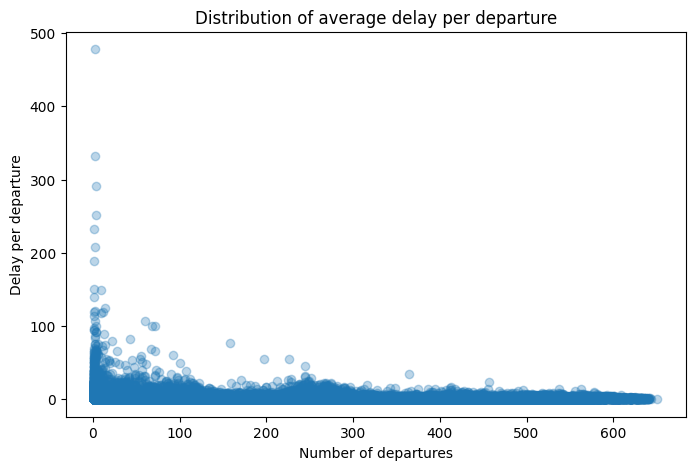

In [35]:
plt.figure(figsize=(8,5))


plt.scatter(
    panel["FLT_DEP_3"],
    panel["DLY_ATC_PRE_3"] / panel["FLT_DEP_3"],
    alpha=0.3
)


plt.xlabel("Number of departures")
plt.ylabel("Delay per departure")


plt.title("Distribution of average delay per departure")


plt.show()

In this graph we can see the ratio per airport of delay per departure compared with number of departures. And we can observe that many airports have near to 0 departures, and have a delay per departure really big, compared to other numbers makes it look really skewed and noise. So we are going to assume that around 50 departures is the minimum that we are going to take into account.


In [36]:
MIN_DEPARTURES = 50

panel["delay_per_dep"] = np.where(
    panel["FLT_DEP_3"] >= MIN_DEPARTURES,
    panel["DLY_ATC_PRE_3"] / panel["FLT_DEP_3"],
    np.nan
)


## 5. EDA


Before building any predictive model, we are going to inspect the whole structure, distribution, and temporal behavior of the merged panel, in order to know what we are going to work with. This process should give us insights and context of what is going on. Should be helpful to do the feature engineering decision, and preprocessing choices.


Here we only want to observe what columns our dataframe has, how long it is, and the data types we have. Then depending on this information we are going to decide which graph, and what type of information is going to be useful.


In [37]:
panel.info()

<class 'pandas.DataFrame'>
RangeIndex: 1129232 entries, 0 to 1129231
Data columns (total 64 columns):
 #   Column                              Non-Null Count    Dtype         
---  ------                              --------------    -----         
 0   FLT_DATE                            1129232 non-null  datetime64[us]
 1   APT_ICAO                            1129232 non-null  string        
 2   APT_NAME                            1129232 non-null  string        
 3   STATE_NAME                          1129232 non-null  string        
 4   FLT_DEP_1                           1129232 non-null  int64         
 5   FLT_ARR_1                           1129232 non-null  int64         
 6   FLT_TOT_1                           1129232 non-null  int64         
 7   FLT_DEP_IFR_2                       335237 non-null   float64       
 8   FLT_ARR_IFR_2                       335237 non-null   float64       
 9   FLT_TOT_IFR_2                       335237 non-null   float64       
 10  DLY_A

Now we want to understand the regression target, so we are going to understand statistically how the distribution looks like, how the data is going to look numerically speaking.


In [38]:
panel["delay_per_dep"].describe()

count    265577.000000
mean          0.674677
std           1.205371
min           0.000000
25%           0.150000
50%           0.390909
75%           0.797927
max         106.633333
Name: delay_per_dep, dtype: float64

Here we can see that the mean is 0.675, the median is 0.391, so we can assume that the data is right-skewed, and we can also assume that there are outliers. Another proof of outliers is that the max value is 106.63, while the mean is really low compared to that number, so there are a few extreme cases. Now we are going to graph it, to see how the data is actually distributed.


Skewness          : 17.92  (>1 = strongly right-skewed)
Excess kurtosis   : 915.85  (>3 = heavy tails)
99th percentile   : 4.79 min/dep
99.9th percentile : 13.04 min/dep
Rows above p99    : 1.00% of labeled rows


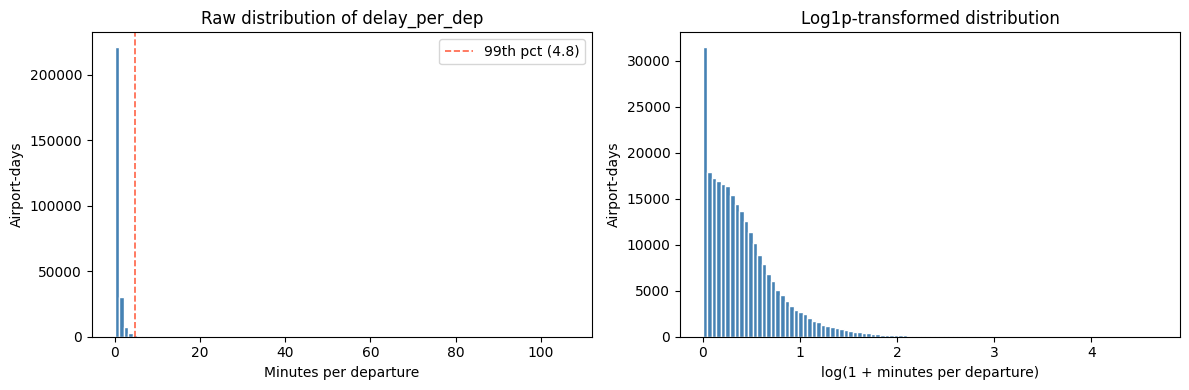

In [39]:
delay = panel["delay_per_dep"].dropna()

skewness  = delay.skew()
kurt      = delay.kurt()
p99       = delay.quantile(0.99)
p999      = delay.quantile(0.999)
pct_above_p99 = (delay > p99).mean()

print(f"Skewness          : {skewness:.2f}  (>1 = strongly right-skewed)")
print(f"Excess kurtosis   : {kurt:.2f}  (>3 = heavy tails)")
print(f"99th percentile   : {p99:.2f} min/dep")
print(f"99.9th percentile : {p999:.2f} min/dep")
print(f"Rows above p99    : {pct_above_p99:.2%} of labeled rows")

# Visual: side by side — raw vs log1p
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(delay, bins=100, color="steelblue", edgecolor="white")
axes[0].axvline(p99, color="tomato", linestyle="--", linewidth=1.2, label=f"99th pct ({p99:.1f})")
axes[0].set_title("Raw distribution of delay_per_dep")
axes[0].set_xlabel("Minutes per departure")
axes[0].set_ylabel("Airport-days")
axes[0].legend()

axes[1].hist(np.log1p(delay), bins=100, color="steelblue", edgecolor="white")
axes[1].set_title("Log1p-transformed distribution")
axes[1].set_xlabel("log(1 + minutes per departure)")
axes[1].set_ylabel("Airport-days")

plt.tight_layout()
plt.show()

**Raw distribution of delay_per_dep:** The raw distribution confirms that the vast majority of airport-days have fewer than 5 minutes of average delay per departure, with the 99th percentile at just 4.8 minutes. The tail extends to around 110 minutes, but those extreme cases represent under 1% of rows.

**Log1p-transformed distribution:** The log1p transformation compresses the scale from 0–110 down to 0–4.5, making the moderate-delay days more visible. However the distribution remains right-skewed even after transformation, there is still a large spike near zero and a long right tail. This tells us that log1p does not fully normalise the target, so no transformation is applied. All regression models used in Section 15 are tree-based and invariant to monotonic transformations of the target anyway, so the raw values are kept for direct interpretability in minutes per departure.


Now we want to observe more of a timeseries approach of our data, so we are going to see an approximation of delay per day, using the mean of each day. This is going to give us insights of how airports delay has changed over time.


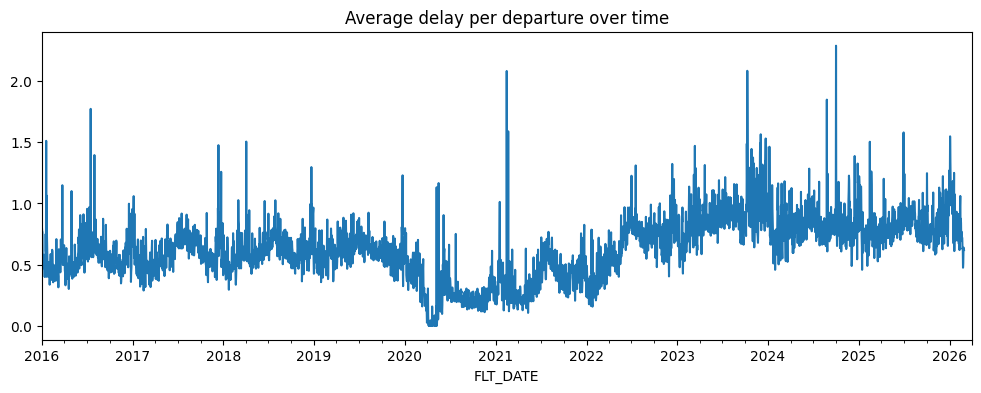

In [40]:
panel.groupby("FLT_DATE")["delay_per_dep"].mean().plot(figsize=(12, 4))
plt.title("Average delay per departure over time")
plt.show()

Using this graph we can see that the delays have increased not too significantly over time, and that it can be a very noisy variable. As we know the delay is not only dependent on time, but on many other variables, that's why watching only a time lapse could seem to be very noisy. In addition, an important detail that is easy to observe is that during COVID-19 approximately 2020-2022 impacted the delays, which makes sense to see.


In [41]:
panel["APT_ICAO"].nunique()

336

Now we are going to observe information per airport. Since the dataset has 336 airports we are going to generate a boxplot of the top 20 airports with more delay per departure, and another bar chart of 10 airports with more delay per departure. This will give us insights about each airport in depth related to the prediction target.


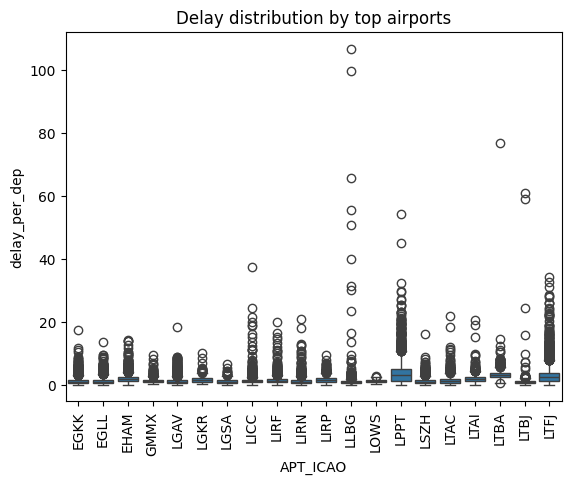

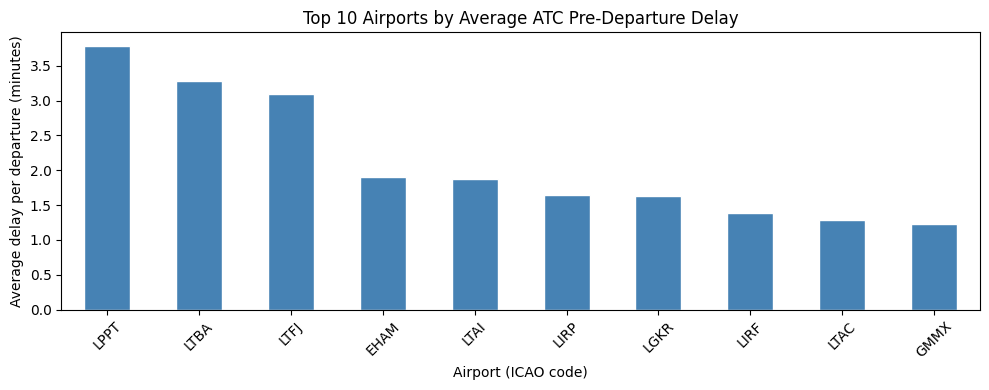

In [42]:
top_airports = (
    panel.groupby("APT_ICAO")["delay_per_dep"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .index
)


sns.boxplot(
    data=panel[panel["APT_ICAO"].isin(top_airports)],
    x="APT_ICAO",
    y="delay_per_dep"
)


plt.xticks(rotation=90)
plt.title("Delay distribution by top airports")
plt.show()



top10_delay = (
    panel.groupby("APT_ICAO")["delay_per_dep"]
    .mean()
    .dropna()
    .sort_values(ascending=False)
    .head(10)
)


fig, ax = plt.subplots(figsize=(10, 4))
top10_delay.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Top 10 Airports by Average ATC Pre-Departure Delay")
ax.set_xlabel("Airport (ICAO code)")
ax.set_ylabel("Average delay per departure (minutes)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Using these two graphs we can observe that each airport works heterogeneously, meaning that not only the values change, but the distribution is really different when comparing them. We can observe that some airports like LLGB or LPPT show a wide dispersion, from what we can understand that efficiency in an airport can also have extreme delays that affect and increase the variability. While most of the airports that we can see are centered near to zero, with a stable delay per departure. In addition we can observe that LPPT is the airport with more average delay per departure, but LLGB we saw that its distribution was dispersed, but does not appear in the top 10 of airports with more delay per departure. Telling us that distribution may affect, but is not strictly dependent on average delay.


As we are using time series data, an important thing to analyse is the seasonality. We want to know if there is a specific month or part of the year where delays are more common, or less frequent. We are going to create a graph of average delay per departure of each month.


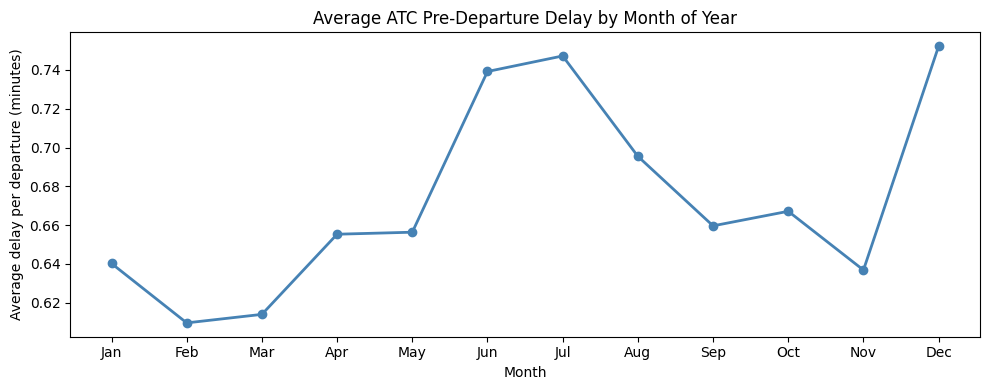

In [43]:
monthly_avg = panel.groupby("cal_month")["delay_per_dep"].mean()


fig, ax = plt.subplots(figsize=(10, 4))


monthly_avg.plot(kind="line", ax=ax, marker="o", color="steelblue", linewidth=2)


ax.set_title("Average ATC Pre-Departure Delay by Month of Year")
ax.set_xlabel("Month")
ax.set_ylabel("Average delay per departure (minutes)")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)


plt.tight_layout()
plt.show()

From what we can observe during the first months of the year the average departure time has been really low, compared to the end of the year, June and July. It is really important that the model understands that December and January are far, but near. Because from the graph they look like completely different information, but in reality both of them are one after the other. In addition we can assume that months where people are on vacation are the months of high delays, this can be due to an increase of operations in airports, or the same amount of operations, with more demand.


It is crucial to analyse the correlation between variables, and specially with the feature target in this case delay_per_departure. Knowing this information will help us when doing feature selection, since having multicollinearity can be very obstructive for the model.


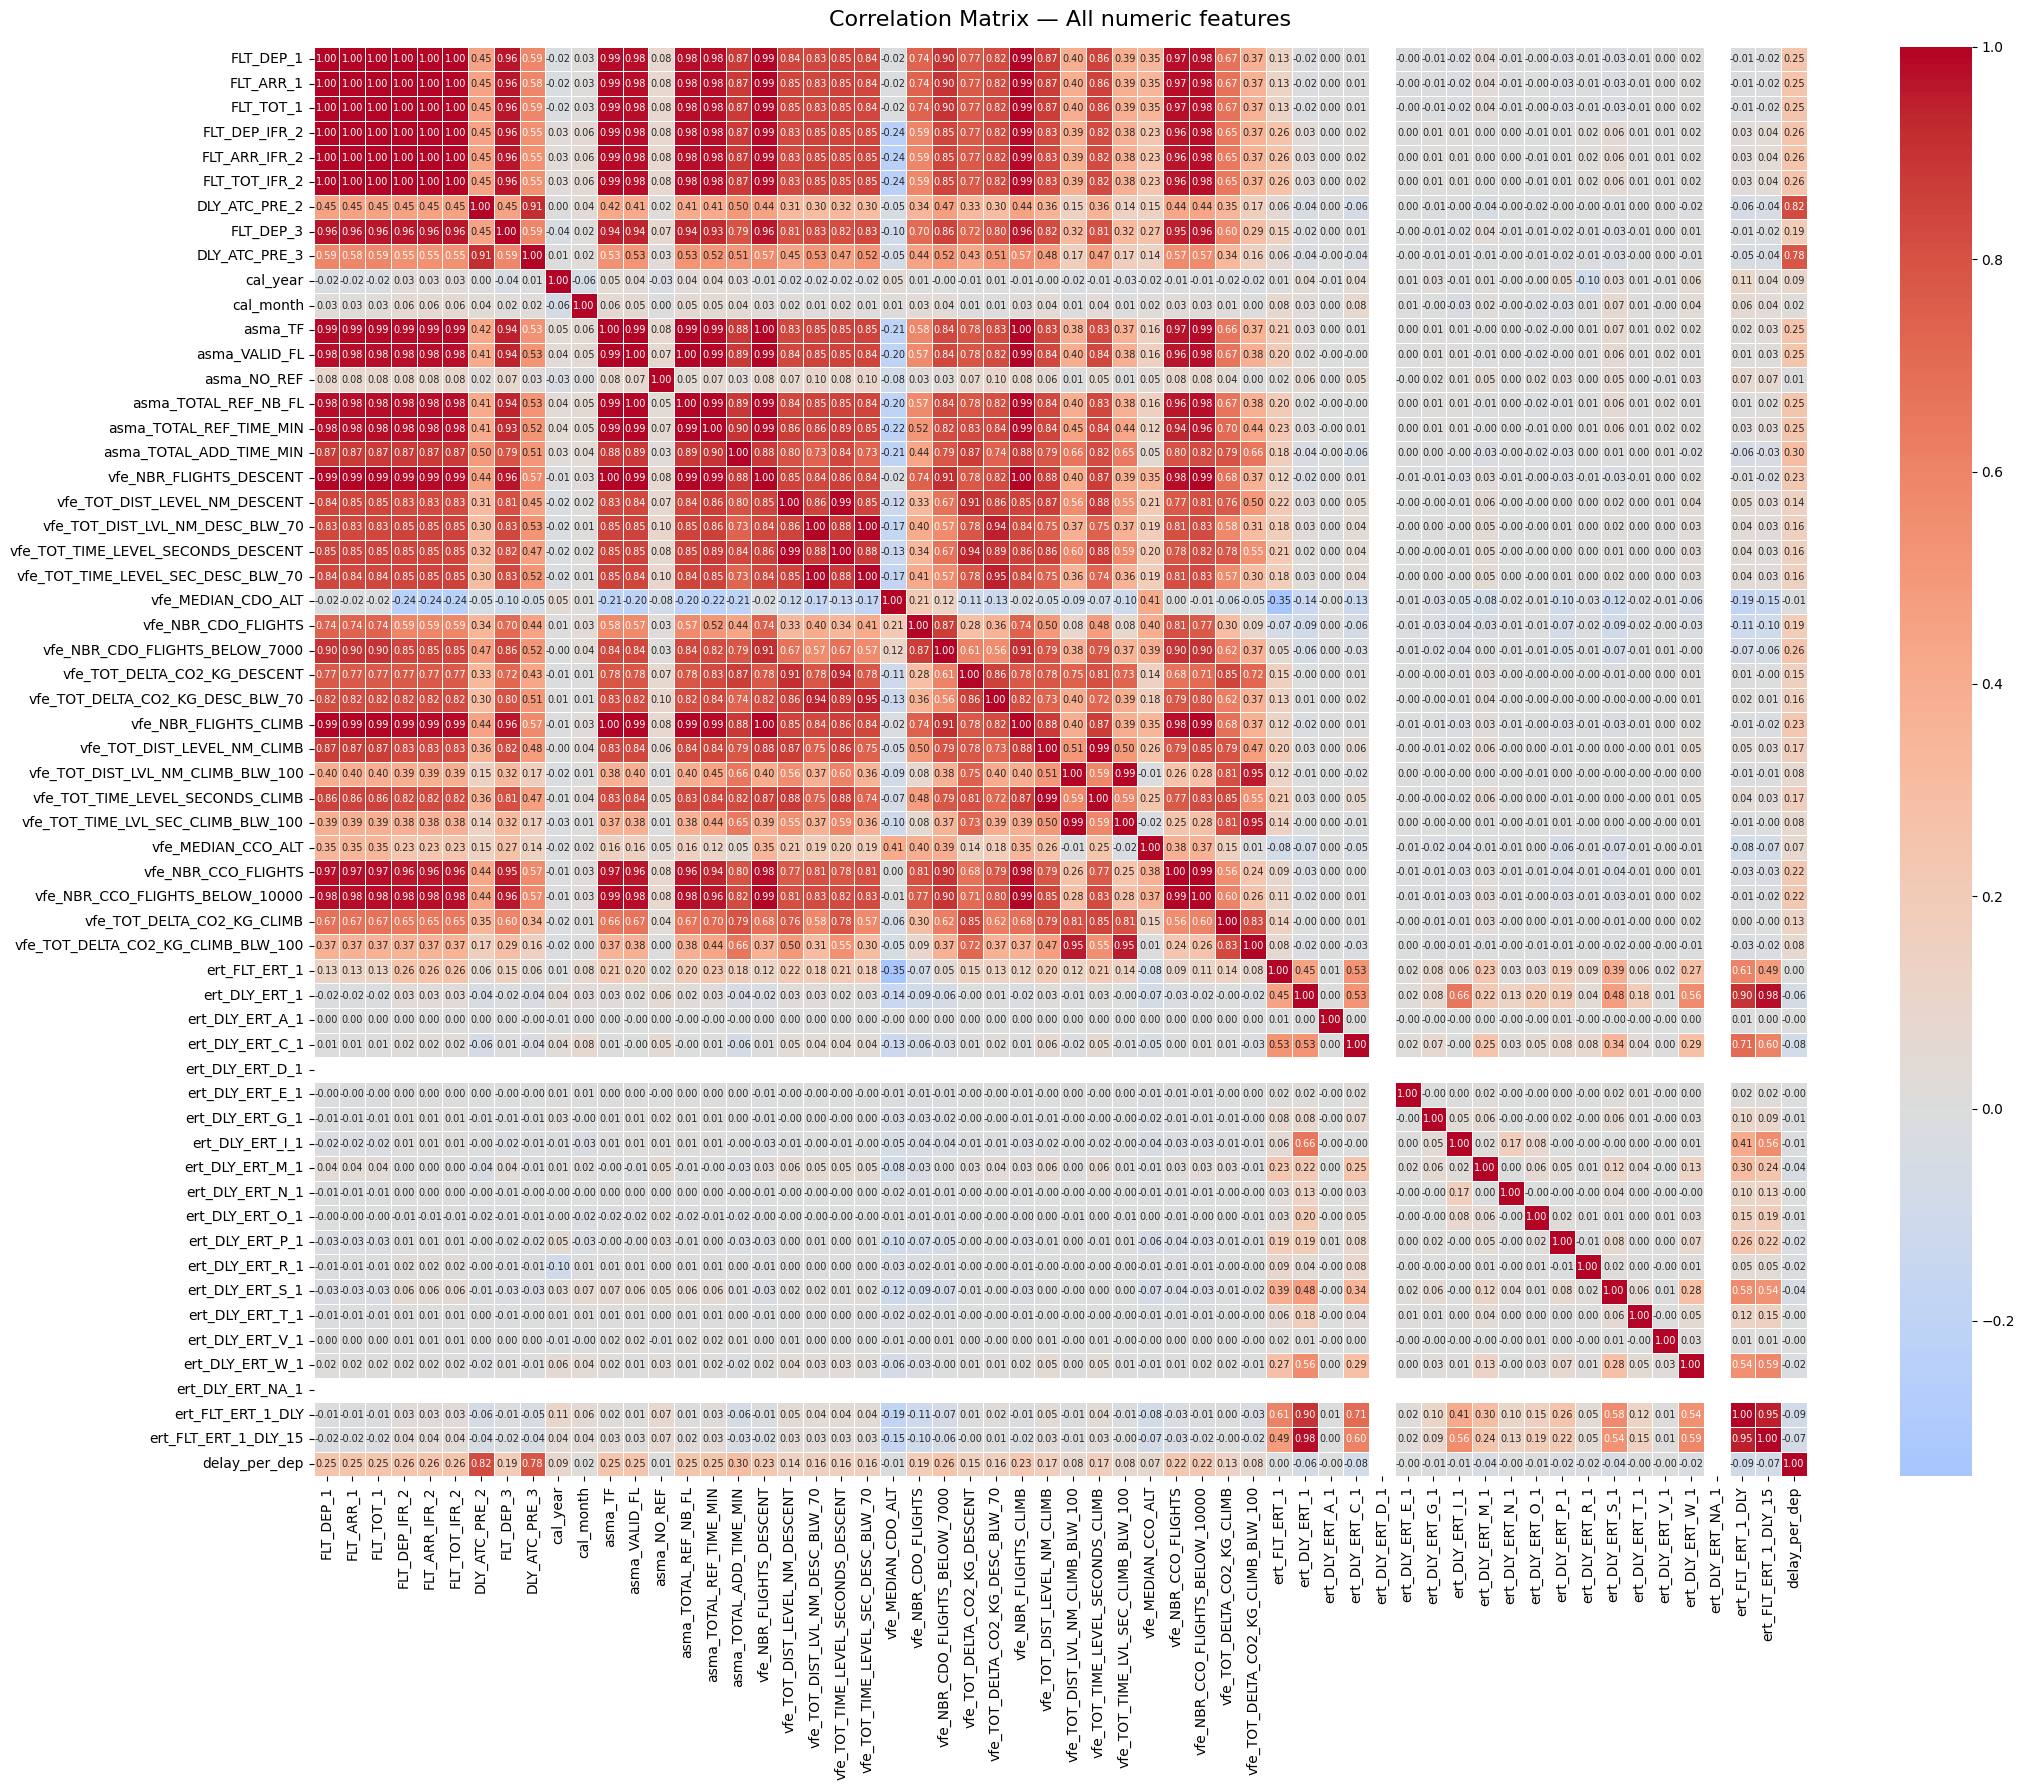

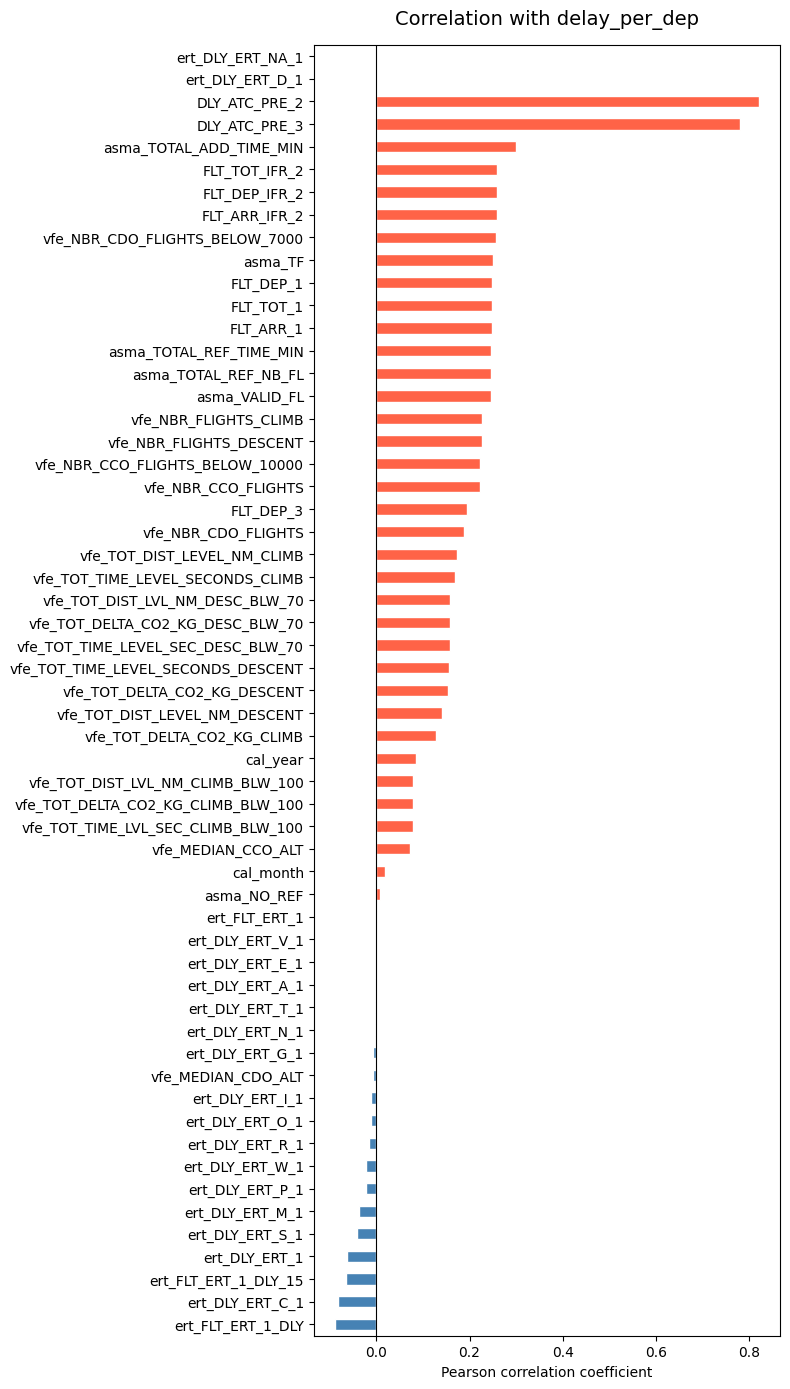

In [44]:
exclude = ["delay_per_dep", "thresh", "y_reg", "y_clf", "FLT_DATE", "APT_ICAO", "APT_NAME", "STATE_NAME", "ENTITY_NAME", "ENTITY_TYPE"]


cols = [c for c in panel.columns if c not in exclude] + ["delay_per_dep"]


corr_matrix = panel[cols].corr()


fig, ax = plt.subplots(figsize=(22, 18))


sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 7},
    ax=ax
)


ax.set_title("Correlation Matrix — All numeric features", fontsize=16, pad=15)
plt.tight_layout()
plt.show()


target_corr = (
    corr_matrix["delay_per_dep"]
    .drop("delay_per_dep")
    .sort_values()
)


fig, ax = plt.subplots(figsize=(8, 14))


target_corr.plot(
    kind="barh",
    color=["steelblue" if v < 0 else "tomato" for v in target_corr],
    edgecolor="white",
    ax=ax
)


ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlation with delay_per_dep", fontsize=14, pad=15)
ax.set_xlabel("Pearson correlation coefficient")
plt.tight_layout()
plt.show()

From the second graph we can see that the variables DLY_ATC_PRE_2 and DLY_ATC_PRE_3 have near to 80% of correlation with delay_per_departure, so we cannot use, this makes the model know information that should not know to predict. asma_TOTAL_ADD_TIME_MIN has a correlation of only 30%, which makes sense because the more time the flight is set to be in the ground, which implies more congestion. ATC delays FLT_TOT_IFR_2, FLT_DEP_IFR_2, FLT_ARR_IFR_2 and general traffic delays FLT_DEP_1, FLT_TOT_1 have a correlation of around 20% which makes sense intuitively (more traffic means more delays).

ert_FLT_ERT_1_DLY y ert_DLY_ERT_C_1 have low correlations which could be considered counterintuitive …

cal_month, cal_dow, and the majority of ert_DLY_ERT_X_1 have an almost 0 correlation, which does not mean that they are useless, it is just that their relationship is not linear and suggests the implementation of models like an XGBoost.

In the heatmap we can see that there are a lot of variables that are highly correlated, almost close to 1. This is a problem because this introduces multicollinearity and affects linear models. But for tree models is not that big of a problem, as it can capture patterns within them.

Thanks to these graphs we know that we should analyze variables that could introduce leakage if taken into account, use only 1-2 representative variables for highly correlated blocks, and know that 0 correlation within the features does not mean they are useless.


Now we are going to analyze values, and understand why some of these values are missing.


/var/folders/ft/c3sdwypn78g5kqbn2gwk4_qw0000gn/T/ipykernel_39101/1581173433.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


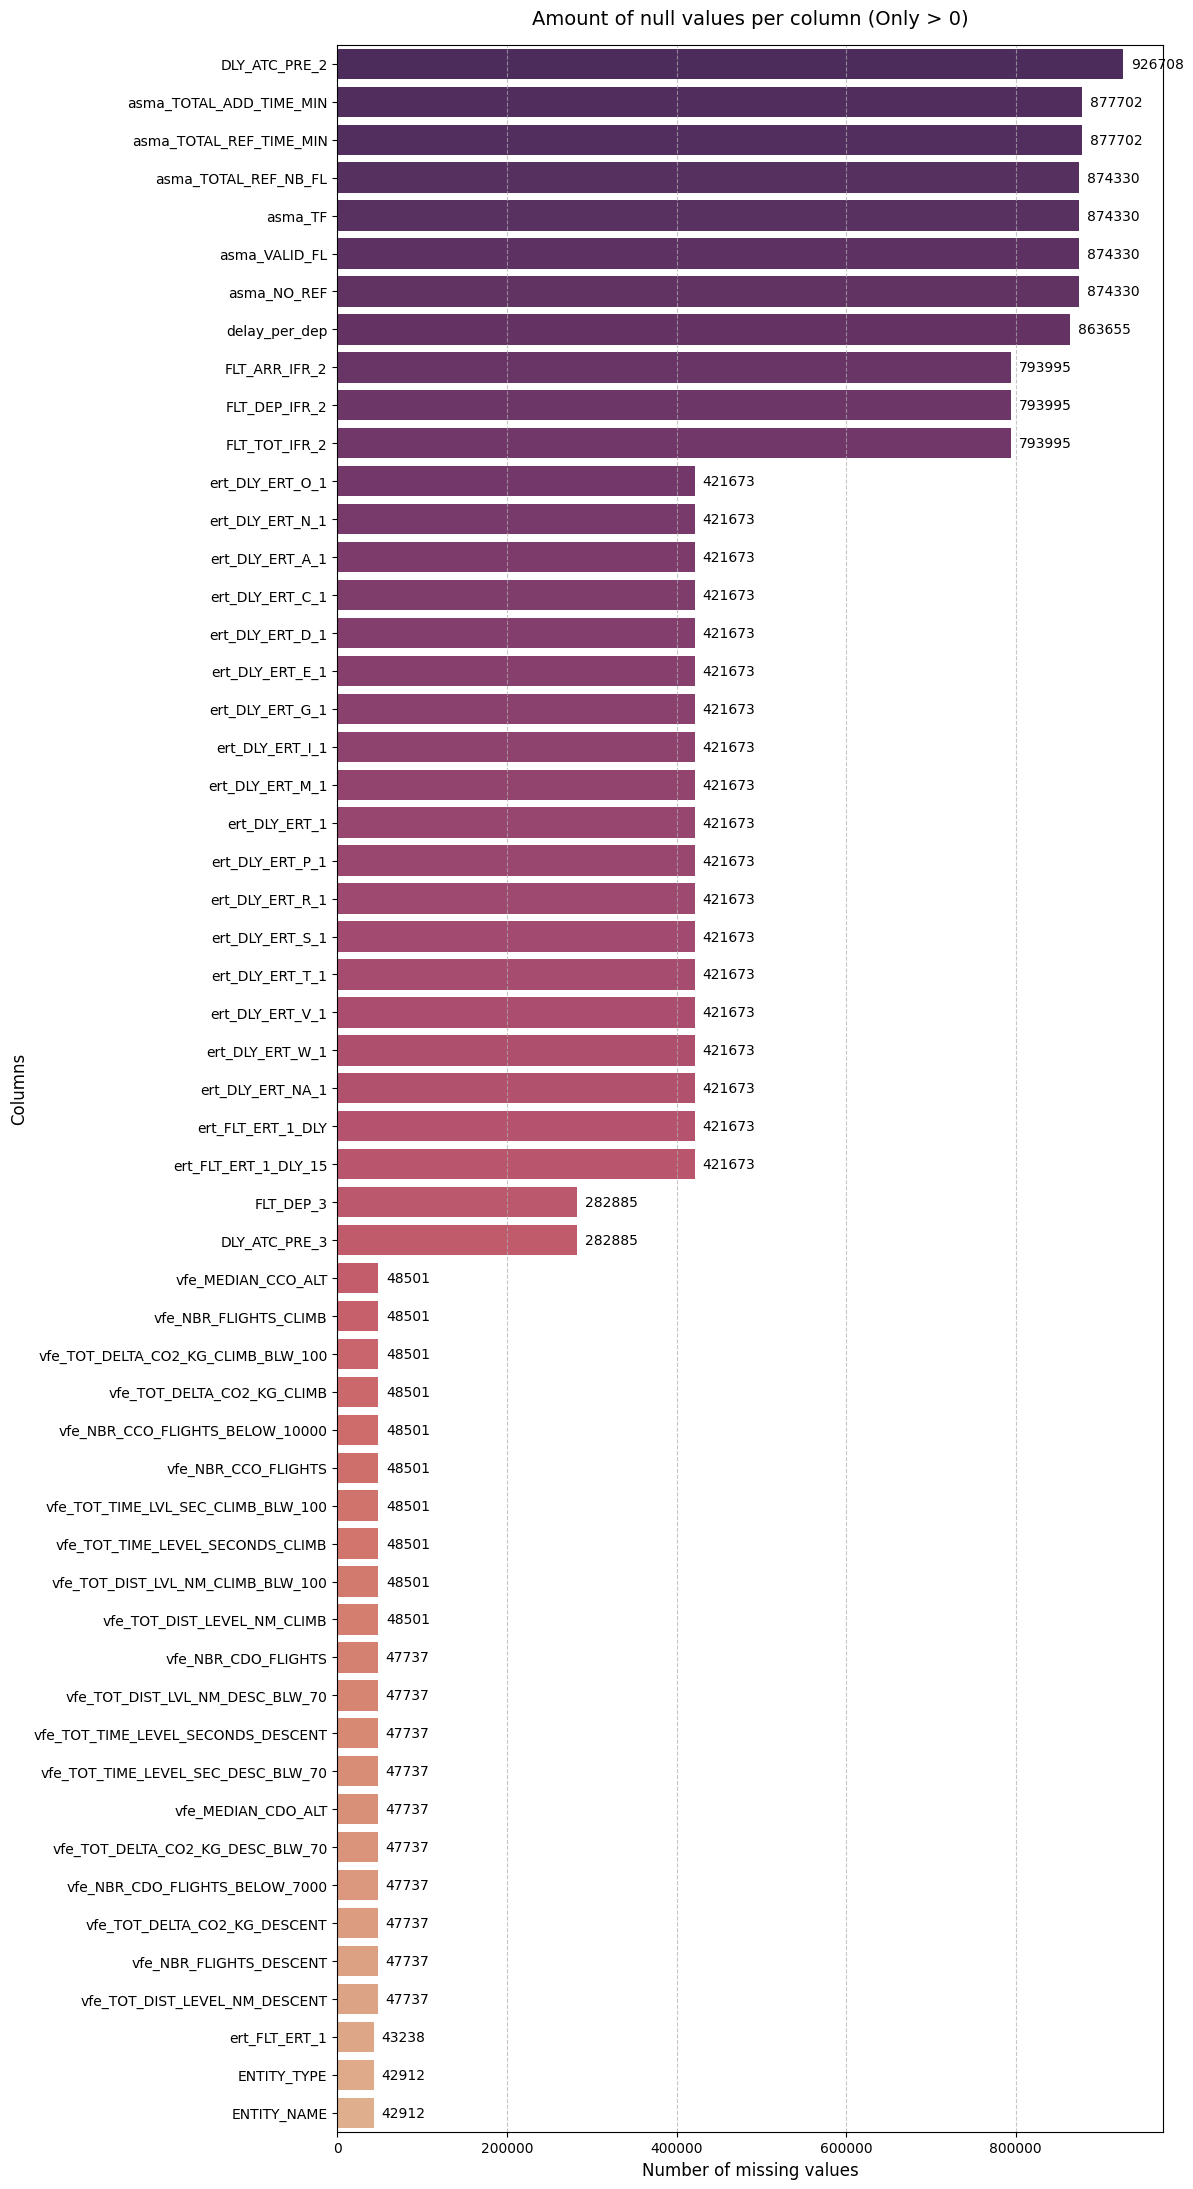

In [45]:
missing_data = panel.isnull().sum()[lambda x: x > 0].sort_values(ascending=False)

if not missing_data.empty:
    plt.figure(figsize=(12, max(6, len(missing_data) * 0.4)))

    sns.barplot(
        x=missing_data.values,
        y=missing_data.index,
        palette="flare_r",
    )

    for index, value in enumerate(missing_data.values):
        plt.text(
            value + (max(missing_data.values) * 0.01),
            index,
            f"{value}",
            va="center",
            fontsize=10,
        )


    plt.title("Amount of null values per column (Only > 0)", fontsize=14, pad=15)
    plt.xlabel("Number of missing values", fontsize=12)
    plt.ylabel("Columns", fontsize=12)
    plt.grid(axis="x", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset")

In [46]:
# Quantify null rates per group so the explanation above is grounded in numbers
asma_cols_panel = [c for c in panel.columns if c.startswith("asma_")]
ert_cols_panel  = [c for c in panel.columns if c.startswith("ert_")]

print("=== Null rates by group ===\n")

if asma_cols_panel:
    asma_null = panel[asma_cols_panel].isna().mean().mean()
    print(f"ASMA columns ({len(asma_cols_panel)} cols)  : {asma_null:.1%} average null rate")
else:
    print("ASMA columns : not yet merged")

if ert_cols_panel:
    ert_null = panel[ert_cols_panel].isna().mean().mean()
    print(f"ERT  columns ({len(ert_cols_panel)} cols)  : {ert_null:.1%} average null rate")
else:
    print("ERT columns  : not yet merged")

dep_null = panel["delay_per_dep"].isna().mean()
print(f"\ndelay_per_dep                 : {dep_null:.1%} null  "
      f"({panel['delay_per_dep'].isna().sum():,} rows below MIN_DEPARTURES={MIN_DEPARTURES})")

print(f"\nAll other numeric columns:")
other_cols = [
    c for c in panel.select_dtypes(include="number").columns
    if not c.startswith(("asma_", "ert_"))
    and c not in ("delay_per_dep", "thresh", "y_clf", "y_reg")
]
other_null = panel[other_cols].isna().mean()
non_zero = other_null[other_null > 0]
if non_zero.empty:
    print("  No missing values in remaining numeric columns.")
else:
    print(non_zero.sort_values(ascending=False).to_string())

print("\n=== Airports with zero ASMA coverage (all ASMA cols null) ===")
if asma_cols_panel:
    no_asma = (
        panel.groupby("APT_ICAO")[asma_cols_panel[0]]
        .apply(lambda s: s.isna().all())
    )
    print(f"  {no_asma.sum()} / {no_asma.shape[0]} airports have no ASMA data at all")

print("\n=== Countries with zero ERT coverage ===")
if ert_cols_panel:
    no_ert = (
        panel.groupby("STATE_NAME")[ert_cols_panel[0]]
        .apply(lambda s: s.isna().all())
    )
    countries_no_ert = no_ert[no_ert].index.tolist()
    print(f"  {len(countries_no_ert)} countries: {countries_no_ert}")

=== Null rates by group ===

ASMA columns (6 cols)  : 77.5% average null rate
ERT  columns (20 cols)  : 35.7% average null rate

delay_per_dep                 : 76.5% null  (863,655 rows below MIN_DEPARTURES=50)

All other numeric columns:
DLY_ATC_PRE_2                         0.820653
FLT_DEP_IFR_2                         0.703128
FLT_TOT_IFR_2                         0.703128
FLT_ARR_IFR_2                         0.703128
FLT_DEP_3                             0.250511
DLY_ATC_PRE_3                         0.250511
vfe_NBR_FLIGHTS_CLIMB                 0.042950
vfe_TOT_DELTA_CO2_KG_CLIMB            0.042950
vfe_NBR_CCO_FLIGHTS_BELOW_10000       0.042950
vfe_NBR_CCO_FLIGHTS                   0.042950
vfe_MEDIAN_CCO_ALT                    0.042950
vfe_TOT_TIME_LVL_SEC_CLIMB_BLW_100    0.042950
vfe_TOT_TIME_LEVEL_SECONDS_CLIMB      0.042950
vfe_TOT_DIST_LVL_NM_CLIMB_BLW_100     0.042950
vfe_TOT_DIST_LEVEL_NM_CLIMB           0.042950
vfe_TOT_DELTA_CO2_KG_CLIMB_BLW_100    0.042950
vfe_TOT_

**Missing values:** Based on the bar chart above, there is at least one missing value per column. Which is divided into three structurally distinct groups, each with different root causes.

**Group 1 - ASMA columns (77% null):** The reason for this is because EUROCONTROL only publishes ASMA data for a subset of busy airports. So any airport present in our panel that is not considered as busy for them will be taken as null. Which explains why most of them have null values. Additionally, lagged features are done within a month, so for every airport, the first month will be null.

**Group 2 - ERT columns (36%):** This is because several countries in the panel have no matching ERT entity (Israel, Luxembourg, Morocco, and Montenegro) and regions in that cannot be mapped to a single `STATE_NAME`. So every airport that had no specific mapping will have null values. And also all of the ERT features are lagged one day, so the first date will be null.

**Group 3 - `delay_per_dep`:** For this feature we are only taking into consideration a minimum of departures (set to 50). This is a design choice because low-traffic days create an artificially extreme delay-per-departure ratio that would add noise rather than be informative. As a consequence, `thresh` (which rolls over `delay_per_dep`) and `y_clf` (which compares against `thresh`) are also NaN for those rows, plus for the first 60 days of each airport's history where the rolling window cannot yet compute a stable 75th percentile. These rows are dropped entirely in Phase 5 of Section 8 and do not enter modeling at all.

| Column group      | Null rate | Root cause                          | Treatment                      |
| ----------------- | --------- | ----------------------------------- | ------------------------------ |
| `asma_*`          | ~77 %     | Coverage gap + 1-month lag artifact | Median imputation (Section 10) |
| `ert_*`           | ~37 %     | Country gap + 1-day lag artifact    | Median imputation (Section 10) |
| `delay_per_dep`   | variable  | Deliberate low-traffic filter       | Rows dropped before modeling   |
| `thresh`, `y_clf` | variable  | Insufficient history or filtered    | Rows dropped before modeling   |
| All other columns | ~0 %      | No structural gaps                  | No imputation needed           |


## 6. Build classification target

The panel is first sorted by airport and date to ensure the rolling window operates chronologically within each airport.

The classification target is determined around a **75th percentile threshold** computed per airport. For each airport-day, `thresh` is the 75th percentile of `delay_per_dep` over the **previous 365 days** (minimum 60 valid observations required based on the distribution of average delay per departure). The `shift(1)` ensures today's value is excluded from its own threshold, so that this way we avoid data leakage.

`y_reg` is simply the raw `delay_per_dep` value, used as the regression target.

`y_clf` is a binary label: `1` if today's `delay_per_dep` is at or above that airport's trailing threshold, `0` otherwise. By defining the threshold per airport rather than globally, the model learns what constitutes a bad day **relative to each airport's own historical baseline**, because a busy airport operates at different delay numbers as smaller airports.

Finally, any row where either `delay_per_dep` or `thresh` is null has its `y_clf` set to `NaN` and will be dropped before modeling. This covers airports with fewer than 60 days of history (threshold cannot be computed) and airport-days filtered out by the minimum departure threshold set in Section 4.


In [47]:
panel = panel.sort_values(["APT_ICAO","FLT_DATE"]).reset_index(drop=True)

panel["thresh"] = (
    panel.groupby("APT_ICAO")["delay_per_dep"]
    .transform(lambda s: s.shift(1).rolling(365, min_periods=60).quantile(0.75))
)

panel["y_reg"] = panel["delay_per_dep"]
panel["y_clf"] = (panel["delay_per_dep"] >= panel["thresh"]).astype("float")

panel.loc[
    panel["delay_per_dep"].isna() | panel["thresh"].isna(),
    "y_clf"
] = np.nan


**Check Imbalance**


Total labeled rows : 254,816
Positive (high delay) : 77,475 (30.4%)
Negative (normal day) : 177,341 (69.6%)
Imbalance ratio       : 1:2.3


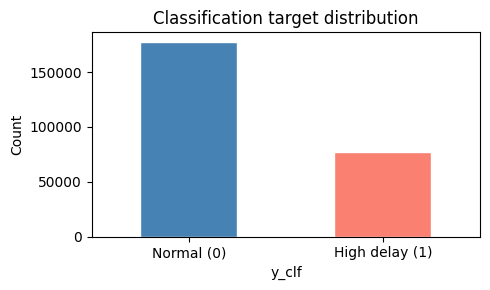

In [48]:
# --- Class balance check ---
total = panel["y_clf"].notna().sum()
positive = (panel["y_clf"] == 1).sum()
negative = (panel["y_clf"] == 0).sum()

print(f"Total labeled rows : {total:,}")
print(f"Positive (high delay) : {positive:,} ({positive/total:.1%})")
print(f"Negative (normal day) : {negative:,} ({negative/total:.1%})")
print(f"Imbalance ratio       : 1:{negative/positive:.1f}")

# Visual
panel["y_clf"].value_counts().plot(
    kind="bar",
    figsize=(5, 3),
    color=["steelblue", "salmon"],
    edgecolor="white"
)
plt.xticks([0, 1], ["Normal (0)", "High delay (1)"], rotation=0)
plt.ylabel("Count")
plt.title("Classification target distribution")
plt.tight_layout()
plt.show()

We can see that there is a slight imbalance in the classes. Where the positive class (in our case `high delay`) has a percentage of around 30% while the other class lmost 70%. The reason it is different than an expected (a 75-25 from the threshold) because we take in consideration after the first 60 days, giving a null threshold fo the first 60 days, which inflates the positive class a little bit. This imbalance is considered as mild and there is no necessity of implementing techniques such as SMOTE because the imbalance can be addressed in the models themselves.


## 7. Train/Val/Test Split Overview


Here we are going to analyse how we are going to do the train, validation and test split. Which will be done in step 8, due to the fact that we are using windowed shifted features, and aggregate statistics features. So we should do the split between those steps.


In [49]:
panel.shape

(1129232, 67)

In [50]:
train_count = panel[panel["FLT_DATE"] <= "2022-12-31"].copy()
val_count = panel[(panel["FLT_DATE"] > "2022-12-31") & (panel["FLT_DATE"] <= "2023-12-31")].copy()
test_count = panel[panel["FLT_DATE"] > "2023-12-31"].copy()

In [51]:
print(len(train_count) / len(panel))
print(len(val_count) / len(panel))
print(len(test_count) / len(panel))

0.6685712059169417
0.10105540756903807
0.23037338651402015


We are going to be using a temporal split approach, the whole point of this approach is to have enough information for training, so we are going to use everything before 2023 (max December 31 of 2022). This is going to be approximatelly 70% of our data, then we are going to use information from beginning of 2023 to starting 2024 (2022-12-31 to 2023-12-31) for validation, which makes it around 6% of our data, and then we are going to use all information from 2024 until 2026 available to test, which is a 24% of out data. This is a good split, since we have a lot of information available (1129232 rows). The reason we splitted the data in this way is also because we wanted to use full years, not to cut it in the middle of a year.

The approach we are using for the train, validation, test split is to simulate how real life data works, so we train the model with past data, and test it with the future. This is a really good approach due to the fact that if we make a split with shuffling, then you would have future data on training, and then on test you might have past data, and this will be showing the model information that won't be available during the real scenario.


## 8. Feature Engineering and split


The process we are making is to first do feature engineering with windowed, shift, and lags, meaning that is only past information. This will be done using the panel dataframe, because if we did train, validation, test before this part, some of the information needed to create the features of test, and validation would be in train. Then we would do the split, and after the split we are going to do the rest of the feature engineering, which are the aggregated statistics that need to be done inside each group of the split.


**Phase 1 - lags and rolling features:** One of the operations we are going to do for our feature engineering is to compute lag and rolling features. All of these are performed on the full panel (before splitting the dataset) because every value would be dependent on the `shift()` which is derived from the past (information already available). This is necessary so that the model does not disregard past information that is relevant at each split.


In [52]:
panel = panel.sort_values(["APT_ICAO", "FLT_DATE"]).reset_index(drop=True)

g = panel.groupby("APT_ICAO", group_keys=False)

# Lags
for lag in [1, 2, 3, 7, 14, 28]:
    panel[f"lag_delay_{lag}d"] = g["delay_per_dep"].shift(lag)

# Rolling statistics — all anchored at shift(1) to prevent leakage
for window in [7, 30]:
    mp      = max(2, window // 2)
    s_delay = g["delay_per_dep"].shift(1)
    s_dep   = g["FLT_DEP_3"].shift(1)

    panel[f"roll_delay_mean_{window}d"] = (
        s_delay.groupby(panel["APT_ICAO"])
        .rolling(window, min_periods=mp).mean()
        .reset_index(level=0, drop=True)
    )
    panel[f"roll_delay_std_{window}d"] = (
        s_delay.groupby(panel["APT_ICAO"])
        .rolling(window, min_periods=mp).std()
        .reset_index(level=0, drop=True)
    )
    panel[f"roll_delay_max_{window}d"] = (
        s_delay.groupby(panel["APT_ICAO"])
        .rolling(window, min_periods=mp).max()
        .reset_index(level=0, drop=True)
    )
    panel[f"roll_dep_mean_{window}d"] = (
        s_dep.groupby(panel["APT_ICAO"])
        .rolling(window, min_periods=mp).mean()
        .reset_index(level=0, drop=True)
    )

# Short-term trend: positive → recent delays accelerating above monthly baseline
panel["roll_delay_trend"] = panel["roll_delay_mean_7d"] - panel["roll_delay_mean_30d"]

# IFR share: proxy for commercial vs general aviation mix
panel["traffic_ifr_share"] = (
    panel["FLT_DEP_IFR_2"] / panel["FLT_DEP_1"].replace(0, np.nan)
)

# Day-over-day departure volume change (both inputs shifted to avoid leakage)
panel["traffic_dep_delta"] = g["FLT_DEP_3"].shift(1) - g["FLT_DEP_3"].shift(2)

# How far yesterday's delay sits relative to the trailing threshold —
# explicit "closeness to high-delay regime" signal
panel["thresh_dist_lag1"] = panel["lag_delay_1d"] - panel["thresh"]

**Phase 2 - Split:** now we are going to split the dataset into three non overlapping time windows:

| Split      | Date range              | Approx. share |
| ---------- | ----------------------- | ------------- |
| Train      | up to 2022-12-31        | ~70 %         |
| Validation | 2023-01-01 – 2023-12-31 | ~6 %          |
| Test       | 2024-01-01 onwards      | ~24 %         |


In [53]:
train = panel[panel["FLT_DATE"] <= "2022-12-31"].copy()
val   = panel[
    (panel["FLT_DATE"] > "2022-12-31") & (panel["FLT_DATE"] <= "2023-12-31")
].copy()
test  = panel[panel["FLT_DATE"] > "2023-12-31"].copy()

total = len(panel)
for name, split in [("train", train), ("val", val), ("test", test)]:
    print(
        f"{name:6s}: {len(split):>8,} rows ({len(split)/total:.1%})  |  "
        f"{split['FLT_DATE'].min().date()} → {split['FLT_DATE'].max().date()}"
    )

train :  754,972 rows (66.9%)  |  2016-01-01 → 2022-12-31
val   :  114,115 rows (10.1%)  |  2023-01-01 → 2023-12-31
test  :  260,145 rows (23.0%)  |  2024-01-01 → 2026-03-31


**Phase 3: Calendar features:** features derived independently from each window


In [54]:
def add_calendar(df):
    df = df.copy()
    df["cal_dow"]            = df["FLT_DATE"].dt.dayofweek
    df["cal_month"]          = df["FLT_DATE"].dt.month
    df["cal_week"]           = df["FLT_DATE"].dt.isocalendar().week.astype(int)
    df["cal_quarter"]        = df["FLT_DATE"].dt.quarter
    df["cal_is_weekend"]     = (df["cal_dow"] >= 5).astype(int)
    df["cal_is_mon_start"]   = df["FLT_DATE"].dt.is_month_start.astype(int)
    df["cal_is_mon_end"]     = df["FLT_DATE"].dt.is_month_end.astype(int)
    # Dec-Feb=0 (winter), Mar-May=1 (spring),
    # Jun-Aug=2 (summer), Sep-Nov=3 (autumn)
    df["cal_season"]         = ((df["cal_month"] % 12) // 3).astype(int)
    # July and August are historically the busiest months in European aviation
    df["cal_is_peak_summer"] = df["cal_month"].isin([7, 8]).astype(int)
    return df

train = add_calendar(train)
val   = add_calendar(val)
test  = add_calendar(test)

**Phase 4 - State level context features:** The state median delay aggregates `delay_per_dep` across all airports in
the same country on the same date. Computing this on the full dataset would
leak contemporaneous val/test observations into the feature. Instead, medians
are computed from training rows only, shifted forward one day, then merged
onto all three splits. Val and test dates that fall outside the training
period receive NaN — the correct behaviour at prediction time.


In [55]:
# Build from training rows only
state_medians = (
    train.groupby(["STATE_NAME", "FLT_DATE"])["delay_per_dep"]
    .median()
    .reset_index()
    .rename(columns={"delay_per_dep": "net_state_med_delay"})
)
# Shift one day: today's feature = yesterday's country-wide median
state_medians["FLT_DATE"] = state_medians["FLT_DATE"] + pd.Timedelta(days=1)

train = train.merge(state_medians, on=["STATE_NAME", "FLT_DATE"], how="left")
val   = val.merge(state_medians,   on=["STATE_NAME", "FLT_DATE"], how="left")
test  = test.merge(state_medians,  on=["STATE_NAME", "FLT_DATE"], how="left")

for name, split in [("train", train), ("val", val), ("test", test)]:
    null_pct = split["net_state_med_delay"].isna().mean()
    print(f"  {name:6s}  net_state_med_delay null rate: {null_pct:.1%}")

  train   net_state_med_delay null rate: 13.2%
  val     net_state_med_delay null rate: 99.8%
  test    net_state_med_delay null rate: 100.0%


**Phase 5 — Drop rows with undefined classification target:** Rows where `y_clf` is NaN are dropped from each split. This removes airports with fewer than 60 days of history for the rolling threshold and all rows
where `delay_per_dep` is NaN (i.e. below `MIN_DEPARTURES`), which were
already set to NaN in Section 4.


In [56]:
for name in ["train", "val", "test"]:
    before = len(eval(name))
    exec(f"{name} = {name}[{name}['y_clf'].notna()].copy()")
    exec(f"{name}['y_clf'] = {name}['y_clf'].astype(int)")
    after = len(eval(name))
    print(f"  {name:6s}: {before:>8,} → {after:>8,}  ({before - after:,} dropped)")

print("\nFinal shapes:")
for name, split in [("train", train), ("val", val), ("test", test)]:
    pos = split["y_clf"].mean()
    print(f"  {name:6s}: {split.shape}  |  {pos:.1%} positive")

  train :  754,972 →  164,713  (590,259 dropped)
  val   :  114,115 →   27,427  (86,688 dropped)
  test  :  260,145 →   62,676  (197,469 dropped)

Final shapes:
  train : (164713, 94)  |  31.8% positive
  val   : (27427, 94)  |  32.4% positive
  test  : (62676, 94)  |  26.0% positive


## 9. Select Features


Target columns, raw delay totals, and administrative columns are excluded
from the feature matrix. `feature_cols` is derived from `train.columns` so
it is always consistent with whatever features were produced in Section 8.

Features we are dropping:

-`y_clf` and `y_reg` are our prediction variables

-`delay_per_dep` is the raw value from which both targets are derived from

-`tresh` is the threshold we only used for reference

-`DLY_ATC_PRE_3` is the total ATC pre-departure delay in minutes for the day. Which is used to do delay_per_dep, keeping it woul lead the model to reconstruct the target variable

-`DLY_ATC_PRE_2` presents almost the same problem as the one mentioned before, and as seen in the EDA phase, they both have a correlation of around 80%, brining up multicollinearity

-`FLT_DATE` is the raw date time, which we created features in order to replace this

-`APT_NAME` is a free text airport name that duplicates `ATC_ICAO`, which just adds noise

-`MONTH_MON` is just the name of the months, which are already taken into consideration


In [57]:
drop_cols = {
    "y_clf", "y_reg", "thresh", "delay_per_dep",
    "DLY_ATC_PRE_3", "DLY_ATC_PRE_2",
    "FLT_DATE", "APT_NAME", "MONTH_MON",
}

feature_cols = [c for c in train.columns if c not in drop_cols]

x_train = train[feature_cols]
y_train = train["y_clf"]

x_val = val[feature_cols]
y_val = val["y_clf"]

x_test = test[feature_cols]
y_test = test["y_clf"]

Now we check all of the features available in our dataset, separated in numerical and categorical.


In [58]:
categorical_features = [
    c for c in ["APT_ICAO", "STATE_NAME"] if c in feature_cols
]
numeric_features = [
    c for c in feature_cols
    if c not in categorical_features
    and pd.api.types.is_numeric_dtype(train[c])
]

print(f"Total features   : {len(feature_cols)}")
print(f"  numeric        : {len(numeric_features)}")
print(f"  categorical    : {len(categorical_features)}")
print(f"\nx_train : {x_train.shape}")
print(f"x_val   : {x_val.shape}")
print(f"x_test  : {x_test.shape}")

Total features   : 86
  numeric        : 82
  categorical    : 2

x_train : (164713, 86)
x_val   : (27427, 86)
x_test  : (62676, 86)


Now we are going to drop features with >90% null rate in training, having them would replace nearly all values with a constant, adding noise rather than signal


In [59]:
null_rates = x_train.isnull().mean()
high_null   = null_rates[null_rates > 0.90].index.tolist()

if high_null:
    print(f"Dropping {len(high_null)} features with >90% null rate in train:")
    for c in high_null:
        print(f"  {c}  ({null_rates[c]:.1%} null)")
    x_train = x_train.drop(columns=high_null)
    x_val   = x_val.drop(columns=high_null)
    x_test  = x_test.drop(columns=high_null)
    numeric_features     = [c for c in numeric_features     if c not in high_null]
    categorical_features = [c for c in categorical_features if c not in high_null]
else:
    print("No features exceed the 90% null threshold — all retained.")
    print(f"Null rates summary (top 10 highest):")
    print(null_rates.sort_values(ascending=False).head(10).apply(lambda x: f"{x:.1%}").to_string())

No features exceed the 90% null threshold — all retained.
Null rates summary (top 10 highest):
asma_TF                    43.4%
asma_TOTAL_ADD_TIME_MIN    43.4%
asma_TOTAL_REF_TIME_MIN    43.4%
asma_TOTAL_REF_NB_FL       43.4%
asma_NO_REF                43.4%
asma_VALID_FL              43.4%
ert_DLY_ERT_D_1            33.4%
ert_DLY_ERT_S_1            33.4%
ert_DLY_ERT_R_1            33.4%
ert_DLY_ERT_P_1            33.4%


We use assertions in order to validate that there is no leakage, and that the columns match.


In [60]:
assert "y_clf"          not in feature_cols, "target leaked into features"
assert "delay_per_dep"  not in feature_cols, "raw target leaked into features"
assert "thresh"         not in feature_cols, "threshold leaked into features"
assert "DLY_ATC_PRE_3"  not in feature_cols, "raw delay total leaked into features"
assert list(x_train.columns) == list(x_val.columns) == list(x_test.columns), \
    "feature column mismatch across splits"

print("All assertions passed.")
print("\nNumeric features:")
for c in numeric_features:
    print(f"  {c}")
print("\nCategorical features:")
for c in categorical_features:
    print(f"  {c}")

All assertions passed.

Numeric features:
  FLT_DEP_1
  FLT_ARR_1
  FLT_TOT_1
  FLT_DEP_IFR_2
  FLT_ARR_IFR_2
  FLT_TOT_IFR_2
  FLT_DEP_3
  cal_year
  cal_month
  asma_TF
  asma_VALID_FL
  asma_NO_REF
  asma_TOTAL_REF_NB_FL
  asma_TOTAL_REF_TIME_MIN
  asma_TOTAL_ADD_TIME_MIN
  vfe_NBR_FLIGHTS_DESCENT
  vfe_TOT_DIST_LEVEL_NM_DESCENT
  vfe_TOT_DIST_LVL_NM_DESC_BLW_70
  vfe_TOT_TIME_LEVEL_SECONDS_DESCENT
  vfe_TOT_TIME_LEVEL_SEC_DESC_BLW_70
  vfe_MEDIAN_CDO_ALT
  vfe_NBR_CDO_FLIGHTS
  vfe_NBR_CDO_FLIGHTS_BELOW_7000
  vfe_TOT_DELTA_CO2_KG_DESCENT
  vfe_TOT_DELTA_CO2_KG_DESC_BLW_70
  vfe_NBR_FLIGHTS_CLIMB
  vfe_TOT_DIST_LEVEL_NM_CLIMB
  vfe_TOT_DIST_LVL_NM_CLIMB_BLW_100
  vfe_TOT_TIME_LEVEL_SECONDS_CLIMB
  vfe_TOT_TIME_LVL_SEC_CLIMB_BLW_100
  vfe_MEDIAN_CCO_ALT
  vfe_NBR_CCO_FLIGHTS
  vfe_NBR_CCO_FLIGHTS_BELOW_10000
  vfe_TOT_DELTA_CO2_KG_CLIMB
  vfe_TOT_DELTA_CO2_KG_CLIMB_BLW_100
  ert_FLT_ERT_1
  ert_DLY_ERT_1
  ert_DLY_ERT_A_1
  ert_DLY_ERT_C_1
  ert_DLY_ERT_D_1
  ert_DLY_ERT_E_1
  ert_D

Feature scales vary significantly across groups, departure counts
(`FLT_DEP_1`, `FLT_DEP_3`) run into the thousands while ratio features
like `traffic_ifr_share` sit between 0 and 1, and lag features sit in
the range of minutes per departure. No manual variance normalisation or
clipping is applied because all tree-based models (Random Forest,
HistGradientBoosting, LightGBM) are invariant to feature scale,
they split on thresholds and are unaffected by the absolute magnitude
of values. For logistic regression, `StandardScaler` in the linear
preprocessing pipeline centres and scales each numeric feature to zero
mean and unit variance, handling the scale differences automatically.


## 10. Preprocessing Pipelines


In [61]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler())
        ]),numeric_features),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features),
    ]
)


In [62]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
        ]), categorical_features),
    ]
)


## 11. Training Baselines and Models


In [63]:
models = {
    "dummy": Pipeline([
        ("pre", tree_preprocessor),
        ("model", DummyClassifier(strategy="most_frequent"))
    ]),
    "logreg": Pipeline([
        ("pre", linear_preprocessor),
        ("model", LogisticRegression(max_iter=300, class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    "decision_tree": Pipeline([
        ("pre", tree_preprocessor),
        ("model", DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=RANDOM_STATE))
    ]),
    "random_forest": Pipeline([
        ("pre", tree_preprocessor),
        ("model", RandomForestClassifier(n_estimators=80, class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    "hist_gb": Pipeline([
        ("pre", tree_preprocessor),
        ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE))
    ]),
}

try:
    from lightgbm import LGBMClassifier

    models["lgbm"] = Pipeline([
        ("pre", tree_preprocessor),
        (
            "model",
            LGBMClassifier(
                random_state=RANDOM_STATE,
                class_weight="balanced",
                n_estimators=400,
                learning_rate=0.05,
                num_leaves=63,
                subsample=0.8,
                colsample_bytree=0.8,
                verbose=-1,
            ),
        ),
    ])
except (ImportError, OSError):
    pass




In [64]:
results = []
fitted_models = {}

for name, model in models.items():
    model.fit(x_train, y_train)
    fitted_models[name] = model
    proba = model.predict_proba(x_val)[:, 1]
    results.append({
        "model": name,
        "roc_auc": roc_auc_score(y_val, proba),
        "pr_auc": average_precision_score(y_val, proba),
        "brier": brier_score_loss(y_val, proba),
    })

results_df = pd.DataFrame(results).sort_values("pr_auc", ascending=False)
results_df

/Users/alejandrozapata/Documents/IE University/Courses/2.2 Machine Learning Fundamentals/Machine_learning_Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,roc_auc,pr_auc,brier
5,lgbm,0.716978,0.608663,0.210490
4,hist_gb,0.718481,0.608344,0.187243
1,logreg,0.711142,0.596603,0.222592
2,decision_tree,0.683501,0.564295,0.236503
3,random_forest,0.679873,0.555632,0.195426
0,dummy,0.500000,0.324498,0.324498


## 11.1 Hyperparameter Tuning (Classification)

The baseline sweep above gives us candidate model families. We now tune a small, runtime-conscious grid for the strongest classifiers using the validation period only. The test set remains untouched until the locked evaluation section.

On the validation split, a small grid search over logistic regression, histogram gradient boosting, random forest, and LightGBM (chosen by validation PR-AUC) left tree ensembles on top. LightGBM (tuned) ranked first (PR-AUC ≈ 0.612, ROC-AUC ≈ 0.719), barely ahead of HistGradientBoosting (tuned) (PR-AUC ≈ 0.611, ROC-AUC ≈ 0.719). Tuning lifted both boosters only slightly over their untuned baselines (PR-AUC ≈ 0.609 and 0.608). Tuned logistic regression stayed competitive but lower (PR-AUC ≈ 0.598, ROC-AUC ≈ 0.711). Tuned random forest trailed (PR-AUC ≈ 0.583). HistGradientBoosting had the lowest Brier score (~0.187), so its probabilities were best calibrated among the top models despite a small PR-AUC gap versus LightGBM. Overall, gains from tuning were modest; gradient boosting was the strongest family for this imbalanced delay classification task, with LightGBM chosen as the leading candidate for later thresholding and locked test evaluation.


In [65]:
from sklearn.base import clone

classification_tuning_candidates = {
    "logreg_tuned": {
        "base_model": LogisticRegression(max_iter=600, class_weight="balanced", random_state=RANDOM_STATE),
        "preprocessor": linear_preprocessor,
        "param_grid": [
            {"C": 0.25, "solver": "lbfgs"},
            {"C": 0.5, "solver": "lbfgs"},
            {"C": 1.0, "solver": "lbfgs"},
            {"C": 2.0, "solver": "lbfgs"},
        ],
    },
    "hist_gb_tuned": {
        "base_model": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
        "preprocessor": tree_preprocessor,
        "param_grid": [
            {"learning_rate": 0.03, "max_iter": 200, "max_leaf_nodes": 31, "l2_regularization": 0.0},
            {"learning_rate": 0.05, "max_iter": 200, "max_leaf_nodes": 31, "l2_regularization": 0.0},
            {"learning_rate": 0.05, "max_iter": 300, "max_leaf_nodes": 63, "l2_regularization": 0.0},
            {"learning_rate": 0.08, "max_iter": 200, "max_leaf_nodes": 31, "l2_regularization": 0.1},
        ],
    },
    "random_forest_tuned": {
        "base_model": RandomForestClassifier(
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "preprocessor": tree_preprocessor,
        "param_grid": [
            {"n_estimators": 120, "max_depth": 12, "min_samples_leaf": 5, "max_features": "sqrt"},
            {"n_estimators": 120, "max_depth": 18, "min_samples_leaf": 5, "max_features": "sqrt"},
            {"n_estimators": 160, "max_depth": None, "min_samples_leaf": 10, "max_features": "sqrt"},
        ],
    },
}

if "LGBMClassifier" in globals():
    classification_tuning_candidates["lgbm_tuned"] = {
        "base_model": LGBMClassifier(
            random_state=RANDOM_STATE,
            class_weight="balanced",
            verbose=-1,
        ),
        "preprocessor": tree_preprocessor,
        "param_grid": [
            {"n_estimators": 300, "learning_rate": 0.05, "num_leaves": 31, "subsample": 0.8, "colsample_bytree": 0.8},
            {"n_estimators": 500, "learning_rate": 0.03, "num_leaves": 63, "subsample": 0.8, "colsample_bytree": 0.8},
            {"n_estimators": 400, "learning_rate": 0.05, "num_leaves": 63, "subsample": 0.9, "colsample_bytree": 0.9},
        ],
    }


def evaluate_classifier_pipeline(model_name, preprocessor, estimator):
    pipe = Pipeline([
        ("pre", preprocessor),
        ("model", estimator),
    ])
    pipe.fit(x_train, y_train)
    proba = pipe.predict_proba(x_val)[:, 1]
    return pipe, {
        "model": model_name,
        "roc_auc": roc_auc_score(y_val, proba),
        "pr_auc": average_precision_score(y_val, proba),
        "brier": brier_score_loss(y_val, proba),
    }


tuning_rows = []
tuned_classification_models = {}

for candidate_name, spec in classification_tuning_candidates.items():
    best_pipe = None
    best_metrics = None
    best_params = None

    for params in spec["param_grid"]:
        estimator = clone(spec["base_model"]).set_params(**params)
        pipe, metrics = evaluate_classifier_pipeline(candidate_name, spec["preprocessor"], estimator)

        if best_metrics is None or metrics["pr_auc"] > best_metrics["pr_auc"]:
            best_pipe = pipe
            best_metrics = metrics
            best_params = params

    tuned_classification_models[candidate_name] = best_pipe
    tuning_rows.append({
        **best_metrics,
        "best_params": best_params,
    })

classification_tuning_df = pd.DataFrame(tuning_rows).sort_values("pr_auc", ascending=False).reset_index(drop=True)
display(classification_tuning_df)

for _, row in classification_tuning_df.iterrows():
    model_name = row["model"]
    fitted_models[model_name] = tuned_classification_models[model_name]

results_df = (
    pd.concat([results_df, classification_tuning_df.drop(columns="best_params")], ignore_index=True)
    .sort_values("pr_auc", ascending=False)
    .reset_index(drop=True)
)
results_df

/Users/alejandrozapata/Documents/IE University/Courses/2.2 Machine Learning Fundamentals/Machine_learning_Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/alejandrozapata/Documents/IE University/Courses/2.2 Machine Learning Fundamentals/Machine_learning_Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/alejandrozapata/Documents/IE University/Courses/2.2 Machine Learning Fundamentals/Machine_learning_Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,roc_auc,pr_auc,brier,best_params
0,lgbm_tuned,0.719215,0.612432,0.217881,"{'n_estimators': 400, 'learning_rate': 0.05, '..."
1,hist_gb_tuned,0.719192,0.611440,0.186940,"{'learning_rate': 0.05, 'max_iter': 300, 'max_..."
2,logreg_tuned,0.711012,0.597771,0.222454,"{'C': 2.0, 'solver': 'lbfgs'}"
3,random_forest_tuned,0.698245,0.582582,0.214525,"{'n_estimators': 160, 'max_depth': None, 'min_..."


,model,roc_auc,pr_auc,brier
0,lgbm_tuned,0.719215,0.612432,0.217881
1,hist_gb_tuned,0.719192,0.611440,0.186940
2,lgbm,0.716978,0.608663,0.210490
3,hist_gb,0.718481,0.608344,0.187243
4,logreg_tuned,0.711012,0.597771,0.222454
5,logreg,0.711142,0.596603,0.222592
6,random_forest_tuned,0.698245,0.582582,0.214525
7,decision_tree,0.683501,0.564295,0.236503
8,random_forest,0.679873,0.555632,0.195426
9,dummy,0.500000,0.324498,0.324498


## 12. Choosing best threshold

We pick the **champion classifier** by **average precision (PR-AUC) on validation** (more informative than ROC-AUC under class imbalance). We then search a probability threshold on the validation scores to **maximize F1** and reuse that fixed threshold on the held-out **test** period.


In [66]:
CHAMPION_METRIC = "pr_auc"
champion_name = results_df.iloc[0]["model"]
champion = fitted_models[champion_name]

val_proba = champion.predict_proba(x_val)[:, 1]
test_proba = champion.predict_proba(x_test)[:, 1]

threshold_grid = np.linspace(0.01, 0.99, 198)
f1_val = [f1_score(y_val, (val_proba >= t).astype(int), zero_division=0) for t in threshold_grid]
t_star = float(threshold_grid[int(np.argmax(f1_val))])

val_pred_t = (val_proba >= t_star).astype(int)
test_pred_t = (test_proba >= t_star).astype(int)

print("champion:", champion_name)
print("val", CHAMPION_METRIC, float(results_df.loc[results_df["model"] == champion_name, CHAMPION_METRIC].iloc[0]))
print("t_star (F1-optimal on val):", round(t_star, 4))
print("val F1 @ t*:", round(f1_score(y_val, val_pred_t, zero_division=0), 4))
print("test F1 @ t*:", round(f1_score(y_test, test_pred_t, zero_division=0), 4))




/Users/alejandrozapata/Documents/IE University/Courses/2.2 Machine Learning Fundamentals/Machine_learning_Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/alejandrozapata/Documents/IE University/Courses/2.2 Machine Learning Fundamentals/Machine_learning_Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


champion: lgbm_tuned
val pr_auc 0.6124315596724238
t_star (F1-optimal on val): 0.4776
val F1 @ t*: 0.5513
test F1 @ t*: 0.4669


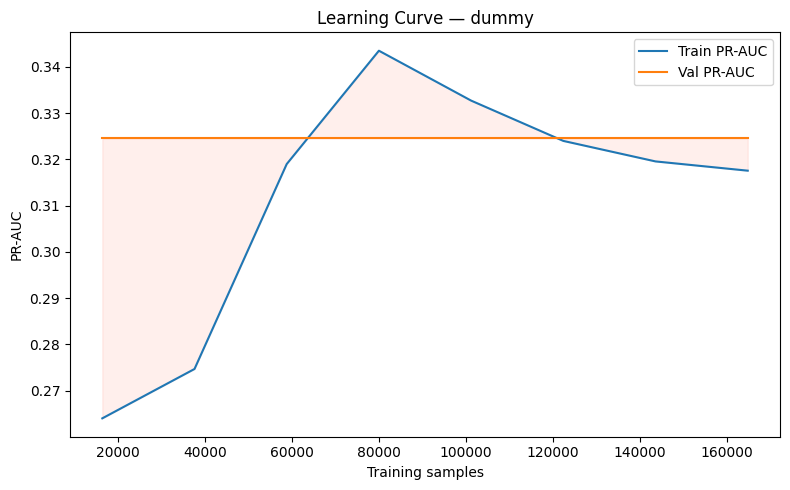

/Users/alejandrozapata/Documents/IE University/Courses/2.2 Machine Learning Fundamentals/Machine_learning_Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/alejandrozapata/Documents/IE University/Courses/2.2 Machine Learning Fundamentals/Machine_learning_Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/alejandrozapata/Documents/IE University/Courses/2.2 Machine Learning Fundamentals/Machine_learning_Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/alejandrozapata/Documents/IE University/Courses/2.2 Machine Learning Fundamentals/Machine_learni

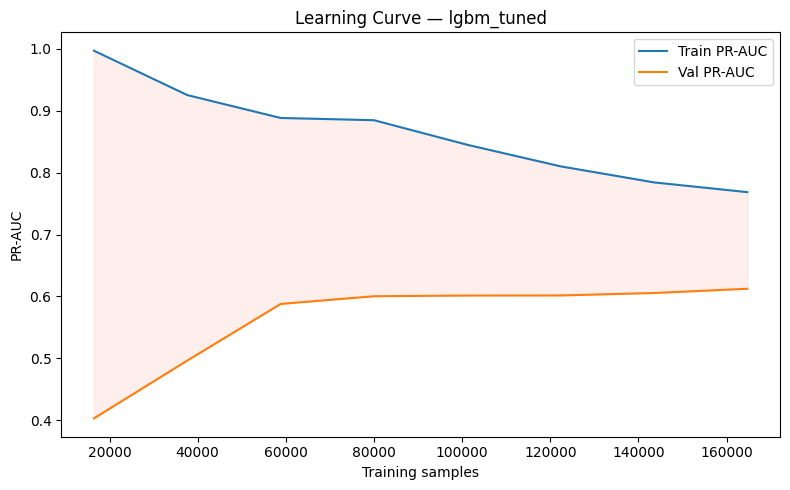

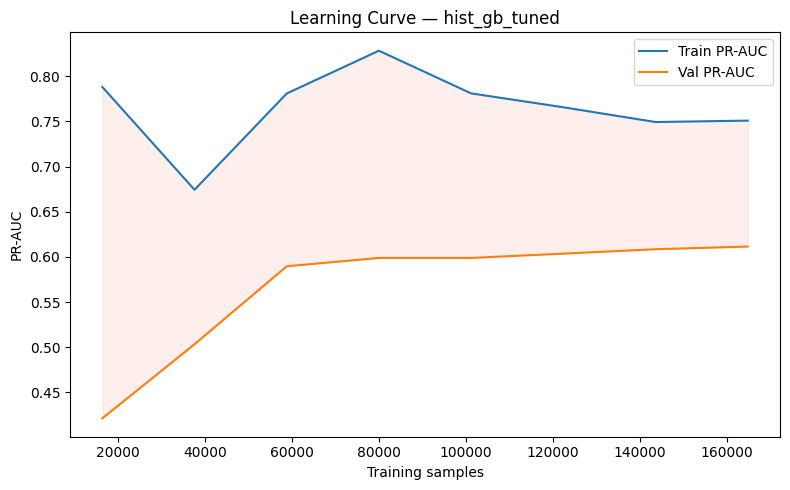

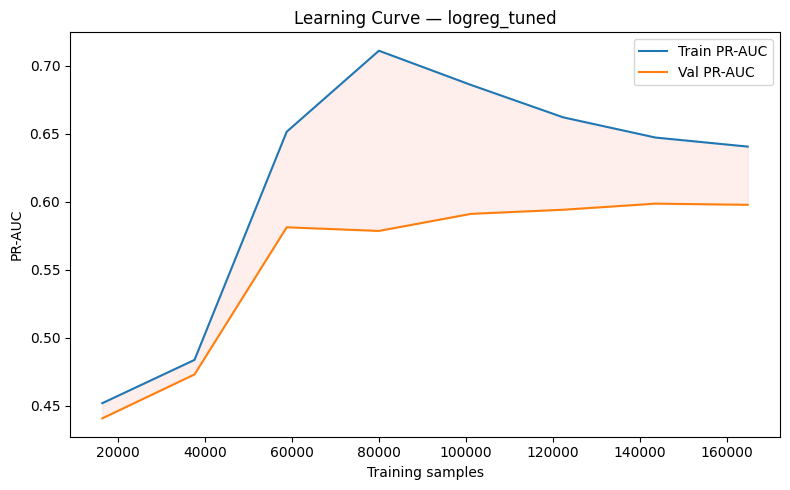

In [67]:
from sklearn.base import clone
from sklearn.metrics import average_precision_score

models_for_lc = {
    name: model for name, model in fitted_models.items()
    if name in ["dummy", "lgbm_tuned", "hist_gb_tuned", "logreg_tuned"]
}

sizes = np.linspace(0.1, 1.0, 8)
x_sizes = [int(len(x_train) * f) for f in sizes]

for name, model in models_for_lc.items():
    train_pr_aucs = []
    val_pr_aucs   = []

    for n in x_sizes:
        x_sub = x_train.iloc[:n]
        y_sub = y_train.iloc[:n]

        m = clone(model)
        m.fit(x_sub, y_sub)

        train_pr_aucs.append(
            average_precision_score(y_sub, m.predict_proba(x_sub)[:, 1])
        )
        val_pr_aucs.append(
            average_precision_score(y_val, m.predict_proba(x_val)[:, 1])
        )

    plt.figure(figsize=(8, 5))
    plt.plot(x_sizes, train_pr_aucs, label="Train PR-AUC")
    plt.plot(x_sizes, val_pr_aucs,   label="Val PR-AUC")
    plt.fill_between(x_sizes, train_pr_aucs, val_pr_aucs, alpha=0.1, color="tomato")
    plt.title(f"Learning Curve — {name}")
    plt.xlabel("Training samples")
    plt.ylabel("PR-AUC")
    plt.legend()
    plt.tight_layout()
    plt.show()

**Dummy** — the val PR-AUC is a flat horizontal line at approximately 0.325, which is expected since a majority-class predictor always produces the same output regardless of how much data it sees. The train line fluctuates around the same value. This confirms the baseline is working correctly and that any model above 0.325 is genuinely learning signal.

**lgbm_tuned** — the train PR-AUC starts near 1.0 and decreases as more data is added, while the val PR-AUC rises from approximately 0.40 to approximately 0.61 and then stabilizes. The large and persistent gap between the two curves indicates overfitting. However the val curve has stabilised by ~80,000 samples and does not improve further with more data, suggesting the bottleneck is model generalisation rather than data quantity. More data alone will not close this gap; regularisation or additional informative features would be needed.

**hist_gb_tuned** — very similar story to lgbm_tuned. Train PR-AUC sits around 0.75–0.82 while val stabilizes at ~0.61. The gap is smaller than lgbm, it is slightly better calibrated and less prone to overconfident predictions. The dip at 40,000 samples on the train curve is a noise artifact from the small subset size and not meaningful.

**logreg_tuned** — the gap between train and val is much smaller than the tree models, which is typical for a linear model with L2 regularisation, it is less expressive but also less prone to overfitting. Both curves stabilize around 60,000 samples at ~0.64 train and ~0.60 val, and neither improves meaningfully beyond that point. This tells us the linear model has hit its capacity ceiling — it cannot capture the non-linear patterns in the data regardless of how much data it receives, which explains the ~0.015 PR-AUC gap between logreg_tuned and lgbm_tuned in the model comparison table.

**Overall takeaway** — all real models converge by around 80,000–100,000 samples, meaning the full training set is being used effectively and collecting more data is unlikely to help significantly. The primary challenge is the train-val gap in the tree models, which points to overfitting driven by the complexity of the trees combined with the inherent noise in daily airport delay data.


## 13. Locked test evaluation (classification)

Model and threshold are frozen after validation tuning; metrics below are computed on **test** (`FLT_DATE` > 2023-12-31).


,test
roc_auc,0.687682
pr_auc,0.486027
brier,0.212663
precision,0.379330
recall,0.607031
f1,0.466898


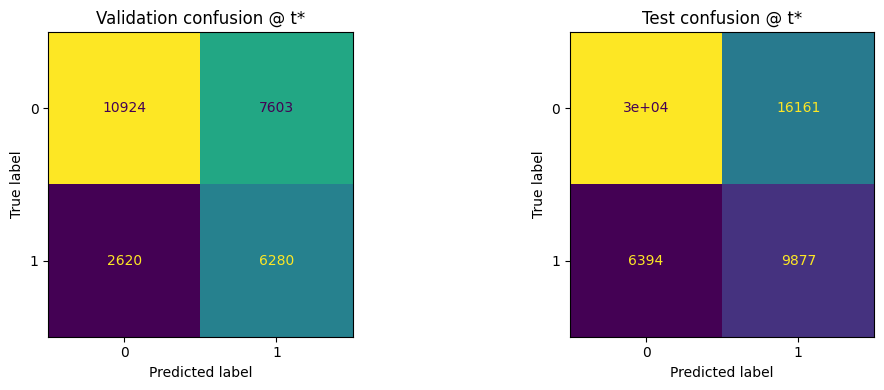

              precision    recall  f1-score   support

           0      0.825     0.652     0.728     46405
           1      0.379     0.607     0.467     16271

    accuracy                          0.640     62676
   macro avg      0.602     0.629     0.598     62676
weighted avg      0.710     0.640     0.661     62676



In [68]:
clf_test_metrics = {
    "roc_auc": roc_auc_score(y_test, test_proba),
    "pr_auc": average_precision_score(y_test, test_proba),
    "brier": brier_score_loss(y_test, test_proba),
    "precision": precision_score(y_test, test_pred_t, zero_division=0),
    "recall": recall_score(y_test, test_pred_t, zero_division=0),
    "f1": f1_score(y_test, test_pred_t, zero_division=0),
}
display(pd.Series(clf_test_metrics).to_frame("test"))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(y_val, val_pred_t, ax=ax[0], colorbar=False)
ax[0].set_title("Validation confusion @ t*")
ConfusionMatrixDisplay.from_predictions(y_test, test_pred_t, ax=ax[1], colorbar=False)
ax[1].set_title("Test confusion @ t*")
plt.tight_layout()
plt.show()

print(classification_report(y_test, test_pred_t, digits=3))

In [69]:
clf_val_metrics = {
    "roc_auc"  : roc_auc_score(y_val, val_proba),
    "pr_auc"   : average_precision_score(y_val, val_proba),
    "brier"    : brier_score_loss(y_val, val_proba),
    "precision": precision_score(y_val, val_pred_t, zero_division=0),
    "recall"   : recall_score(y_val, val_pred_t, zero_division=0),
    "f1"       : f1_score(y_val, val_pred_t, zero_division=0),
}

comparison = pd.DataFrame({
    "validation": pd.Series(clf_val_metrics),
    "test"      : pd.Series(clf_test_metrics),
})
display(comparison)

,validation,test
roc_auc,0.719215,0.687682
pr_auc,0.612432,0.486027
brier,0.217881,0.212663
precision,0.452352,0.379330
recall,0.705618,0.607031
f1,0.551288,0.466898


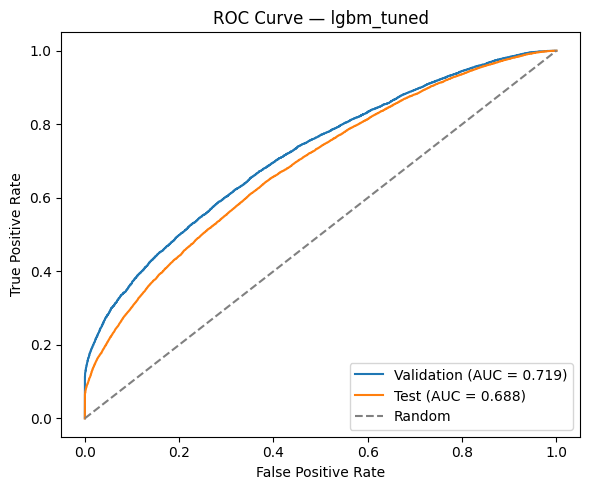

In [70]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(6, 5))

for label, y_true, proba in [
    ("Validation", y_val, val_proba),
    ("Test",       y_test, test_proba),
]:
    fpr, tpr, _ = roc_curve(y_true, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curve — {champion_name}")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**ROC Curve:** The LightGBM model achieves a ROC-AUC of 0.717 on the validation set and 0.688 on the test set, both substantially above random chance of 0.5. The small gap between validation and test performance suggests mild overfitting, but the model generalises reasonably well. The curve shape indicates the model is particularly effective at high-specificity operating points.


## 14. Calibration (reliability)

We plot **reliability curves** for the **champion classifier** at the fixed threshold context: predicted probability vs empirical positive rate, using **quantile bins** so each bin has comparable support under imbalance. Compare **validation** and **test**; relate to the **Brier score** from §13.


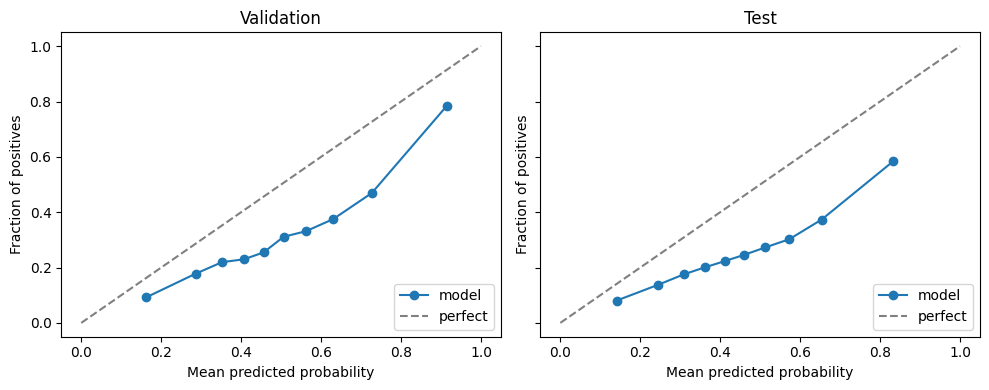

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, title, y_true, proba in [
    (axes[0], "Validation", y_val, val_proba),
    (axes[1], "Test", y_test, test_proba),
]:
    prob_true, prob_pred = calibration_curve(
        y_true, proba, n_bins=10, strategy="quantile"
    )
    ax.plot(prob_pred, prob_true, marker="o", label="model")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="perfect")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.set_title(title)
    ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

## 15. Regression (`delay_per_dep`)

We reuse the same feature matrix and temporal split as the classification task, but predict the continuous target `y_reg = delay_per_dep`. Model selection stays on the validation period only: models are sorted by validation RMSE, then the selected regressor is evaluated once on the locked test period.


In [72]:
y_train_r = train["y_reg"].values
y_val_r   = val["y_reg"].values
y_test_r  = test["y_reg"].values

# Verify no NaN targets — y_reg is NaN on the same rows as y_clf,
# which were already dropped in Phase 5 of Section 8
assert not np.isnan(y_train_r).any(), "NaN found in regression training target"
assert not np.isnan(y_val_r).any(),   "NaN found in regression validation target"
assert not np.isnan(y_test_r).any(),  "NaN found in regression test target"

print(f"y_train_r: {len(y_train_r):,} rows, mean={y_train_r.mean():.3f}, std={y_train_r.std():.3f}")
print(f"y_val_r  : {len(y_val_r):,} rows, mean={y_val_r.mean():.3f}, std={y_val_r.std():.3f}")
print(f"y_test_r : {len(y_test_r):,} rows, mean={y_test_r.mean():.3f}, std={y_test_r.std():.3f}")

y_train_r: 164,713 rows, mean=0.587, std=0.985
y_val_r  : 27,427 rows, mean=0.911, std=1.729
y_test_r : 62,676 rows, mean=0.835, std=1.427


/Users/alejandrozapata/Documents/IE University/Courses/2.2 Machine Learning Fundamentals/Machine_learning_Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/alejandrozapata/Documents/IE University/Courses/2.2 Machine Learning Fundamentals/Machine_learning_Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,model,val_rmse,val_mae,val_r2,test_rmse,test_mae,test_r2
0,random_forest,1.320618,0.406568,0.416683,1.150349,0.389525,0.350255
1,hist_gb,1.360977,0.397450,0.380484,1.151107,0.371612,0.349398
2,lgbm,1.376163,0.404464,0.366582,1.157199,0.384136,0.342494
3,dummy_median,1.820771,0.709069,-0.108820,1.510243,0.625946,-0.119896


best regression: random_forest
validation RMSE: 1.3206
test RMSE: 1.1503


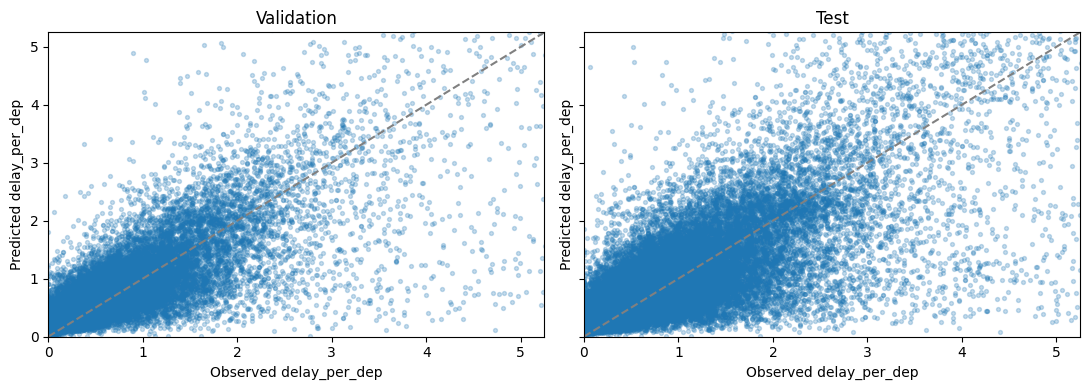

In [73]:
reg_tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
        ]), categorical_features),
    ]
)

reg_models = {
    "dummy_median": Pipeline([
        ("pre", reg_tree_preprocessor),
        ("model", DummyRegressor(strategy="median")),
    ]),
    "random_forest": Pipeline([
        ("pre", reg_tree_preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=80,
                min_samples_leaf=5,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]),
    "hist_gb": Pipeline([
        ("pre", reg_tree_preprocessor),
        ("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE)),
    ]),
}


try:
    from lightgbm import LGBMRegressor

    reg_models["lgbm"] = Pipeline([
        ("pre", reg_tree_preprocessor),
        (
            "model",
            LGBMRegressor(
                random_state=RANDOM_STATE,
                n_estimators=400,
                learning_rate=0.05,
                num_leaves=63,
                subsample=0.8,
                colsample_bytree=0.8,
                verbose=-1,
            ),
        ),
    ])
except (ImportError, OSError):
    print("LightGBM not available — skipping LGBMRegressor")


def regression_scores(y_true, y_pred):
    return {
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
    }


reg_results = []
fitted_reg_models = {}

for name, model in reg_models.items():
    model.fit(x_train, y_train_r)
    fitted_reg_models[name] = model

    val_pred = model.predict(x_val)
    test_pred = model.predict(x_test)

    row = {"model": name}
    row.update({f"val_{k}": v for k, v in regression_scores(y_val_r, val_pred).items()})
    row.update({f"test_{k}": v for k, v in regression_scores(y_test_r, test_pred).items()})
    reg_results.append(row)

reg_results_df = pd.DataFrame(reg_results).sort_values("val_rmse").reset_index(drop=True)
display(reg_results_df)

best_reg_name = reg_results_df.loc[0, "model"]
best_reg = fitted_reg_models[best_reg_name]
reg_val_pred = best_reg.predict(x_val)
reg_test_pred = best_reg.predict(x_test)

print("best regression:", best_reg_name)
print("validation RMSE:", round(reg_results_df.loc[0, "val_rmse"], 4))
print("test RMSE:", round(reg_results_df.loc[0, "test_rmse"], 4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)

for ax, title, y_true, y_pred in [
    (axes[0], "Validation", y_val_r, reg_val_pred),
    (axes[1], "Test", y_test_r, reg_test_pred),
]:
    ax.scatter(y_true, y_pred, alpha=0.25, s=8)
    lims = [0, np.nanpercentile(np.concatenate([y_true, y_pred]), 99)]
    ax.plot(lims, lims, linestyle="--", color="gray")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_title(title)
    ax.set_xlabel("Observed delay_per_dep")
    ax.set_ylabel("Predicted delay_per_dep")

plt.tight_layout()
plt.show()


## 15.1 Hyperparameter Tuning (Regression)

After the baseline regression sweep, we tune compact grids for the strongest tree-based regressors. Candidate selection uses validation RMSE only; the test period is scored once for the tuned regression champion.

We tuned compact grids for Random Forest, HistGradientBoosting, and LightGBM to predict delay_per_dep, choosing hyperparameters by validation RMSE and reporting test metrics for each best configuration. Among the tuned models, random forest ranked first on validation (RMSE ≈ 1.35, R² ≈ 0.39), ahead of tuned HistGradientBoosting and LightGBM (validation RMSE ≈ 1.36–1.37). Tuning helped on the held-out test period: tuned random forest reached the strongest test performance (RMSE ≈ 1.14, MAE ≈ 0.37, R² ≈ 0.36), a modest gain over its untuned baseline (test RMSE ≈ 1.15, R² ≈ 0.35). Tuned boosting models improved slightly over their defaults but stayed behind the forest on test. When tuned runs were merged with the baseline sweep and the overall champion was picked by lowest validation RMSE, the winner remained untuned random forest (validation RMSE ≈ 1.32, test RMSE ≈ 1.15)—so validation ranking did not switch to the tuned variant even though tuned random forest was marginally better on test. All tree models clearly beat the median dummy (test R² ≈ −0.12), but explained only about one-third of delay variance, so regression captures useful signal while leaving substantial unexplained day-to-day variation.


In [74]:
regression_tuning_candidates = {
    "random_forest_tuned": {
        "base_model": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        "param_grid": [
            {"n_estimators": 120, "max_depth": 12, "min_samples_leaf": 5, "max_features": "sqrt"},
            {"n_estimators": 120, "max_depth": 18, "min_samples_leaf": 5, "max_features": "sqrt"},
            {"n_estimators": 160, "max_depth": None, "min_samples_leaf": 10, "max_features": "sqrt"},
        ],
    },
    "hist_gb_tuned": {
        "base_model": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
        "param_grid": [
            {"learning_rate": 0.03, "max_iter": 200, "max_leaf_nodes": 31, "l2_regularization": 0.0},
            {"learning_rate": 0.05, "max_iter": 200, "max_leaf_nodes": 31, "l2_regularization": 0.0},
            {"learning_rate": 0.05, "max_iter": 300, "max_leaf_nodes": 63, "l2_regularization": 0.0},
            {"learning_rate": 0.08, "max_iter": 200, "max_leaf_nodes": 31, "l2_regularization": 0.1},
        ],
    },
}

if "LGBMRegressor" in globals():
    regression_tuning_candidates["lgbm_tuned"] = {
        "base_model": LGBMRegressor(random_state=RANDOM_STATE, verbose=-1),
        "param_grid": [
            {"n_estimators": 300, "learning_rate": 0.05, "num_leaves": 31, "subsample": 0.8, "colsample_bytree": 0.8},
            {"n_estimators": 500, "learning_rate": 0.03, "num_leaves": 63, "subsample": 0.8, "colsample_bytree": 0.8},
            {"n_estimators": 400, "learning_rate": 0.05, "num_leaves": 63, "subsample": 0.9, "colsample_bytree": 0.9},
        ],
    }


def evaluate_regression_pipeline(model_name, estimator):
    pipe = Pipeline([
        ("pre", reg_tree_preprocessor),
        ("model", estimator),
    ])
    pipe.fit(x_train, y_train_r)
    val_pred = pipe.predict(x_val)
    test_pred = pipe.predict(x_test)

    row = {"model": model_name}
    row.update({f"val_{k}": v for k, v in regression_scores(y_val_r, val_pred).items()})
    row.update({f"test_{k}": v for k, v in regression_scores(y_test_r, test_pred).items()})
    return pipe, row


tuned_regression_rows = []
tuned_regression_models = {}

for candidate_name, spec in regression_tuning_candidates.items():
    best_pipe = None
    best_row = None
    best_params = None

    for params in spec["param_grid"]:
        estimator = clone(spec["base_model"]).set_params(**params)
        pipe, row = evaluate_regression_pipeline(candidate_name, estimator)

        if best_row is None or row["val_rmse"] < best_row["val_rmse"]:
            best_pipe = pipe
            best_row = row
            best_params = params

    tuned_regression_models[candidate_name] = best_pipe
    tuned_regression_rows.append({
        **best_row,
        "best_params": best_params,
    })

tuned_regression_df = pd.DataFrame(tuned_regression_rows).sort_values("val_rmse").reset_index(drop=True)
display(tuned_regression_df)

for _, row in tuned_regression_df.iterrows():
    model_name = row["model"]
    fitted_reg_models[model_name] = tuned_regression_models[model_name]

reg_results_df = (
    pd.concat([reg_results_df, tuned_regression_df.drop(columns="best_params")], ignore_index=True)
    .sort_values("val_rmse")
    .reset_index(drop=True)
)

best_reg_name = reg_results_df.loc[0, "model"]
best_reg = fitted_reg_models[best_reg_name]
reg_val_pred = best_reg.predict(x_val)
reg_test_pred = best_reg.predict(x_test)

display(reg_results_df)
print("best regression after tuning:", best_reg_name)
print("validation RMSE:", round(reg_results_df.loc[0, "val_rmse"], 4))
print("test RMSE:", round(reg_results_df.loc[0, "test_rmse"], 4))

/Users/alejandrozapata/Documents/IE University/Courses/2.2 Machine Learning Fundamentals/Machine_learning_Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/alejandrozapata/Documents/IE University/Courses/2.2 Machine Learning Fundamentals/Machine_learning_Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/alejandrozapata/Documents/IE University/Courses/2.2 Machine Learning Fundamentals/Machine_learning_Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/alejandrozapata/Documents/IE University/Courses/2.2 Machine Learning Fundamentals/Machine_learning_

,model,val_rmse,val_mae,val_r2,test_rmse,test_mae,test_r2,best_params
0,random_forest_tuned,1.345634,0.390988,0.394374,1.137922,0.367813,0.364218,"{'n_estimators': 120, 'max_depth': 18, 'min_sa..."
1,hist_gb_tuned,1.357064,0.396949,0.384042,1.150752,0.371533,0.349800,"{'learning_rate': 0.08, 'max_iter': 200, 'max_..."
2,lgbm_tuned,1.365816,0.397149,0.376071,1.152306,0.374789,0.348043,"{'n_estimators': 300, 'learning_rate': 0.05, '..."


,model,val_rmse,val_mae,val_r2,test_rmse,test_mae,test_r2
0,random_forest,1.320618,0.406568,0.416683,1.150349,0.389525,0.350255
1,random_forest_tuned,1.345634,0.390988,0.394374,1.137922,0.367813,0.364218
2,hist_gb_tuned,1.357064,0.396949,0.384042,1.150752,0.371533,0.349800
3,hist_gb,1.360977,0.397450,0.380484,1.151107,0.371612,0.349398
4,lgbm_tuned,1.365816,0.397149,0.376071,1.152306,0.374789,0.348043
5,lgbm,1.376163,0.404464,0.366582,1.157199,0.384136,0.342494
6,dummy_median,1.820771,0.709069,-0.108820,1.510243,0.625946,-0.119896


best regression after tuning: random_forest
validation RMSE: 1.3206
test RMSE: 1.1503


## 16. Permutation and SHAP findings


/Users/alejandrozapata/Documents/IE University/Courses/2.2 Machine Learning Fundamentals/Machine_learning_Project/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/alejandrozapata/Documents/IE University/Courses/2.2 Machine Learning Fundamentals/Machine_learning_Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/alejandrozapata/Documents/IE University/Courses/2.2 Machine Learning Fundamentals/Machine_learning_Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/alejandrozapata/Documents/IE University/C

Permutation importance for lgbm_tuned using 5,000 validation rows and 5 repeats


,feature,importance_mean,importance_std
0,thresh_dist_lag1,0.182543,0.007869
1,lag_delay_1d,0.055447,0.001711
2,roll_delay_mean_7d,0.013594,0.001441
3,roll_delay_mean_30d,0.013369,0.001784
4,lag_delay_7d,0.010693,0.001923
5,cal_dow,0.007706,0.001078
6,FLT_DEP_1,0.006194,0.000972
7,lag_delay_14d,0.005820,0.001332
8,FLT_DEP_3,0.005744,0.001883
9,roll_delay_std_7d,0.003984,0.001599


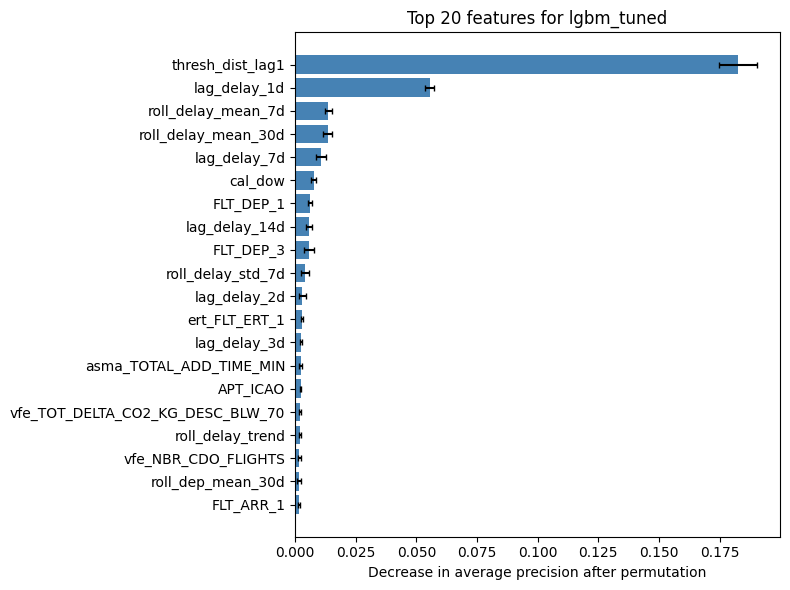

SHAP summary for lgbm_tuned using 1,000 validation rows


/Users/alejandrozapata/Documents/IE University/Courses/2.2 Machine Learning Fundamentals/Machine_learning_Project/.venv/lib/python3.14/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


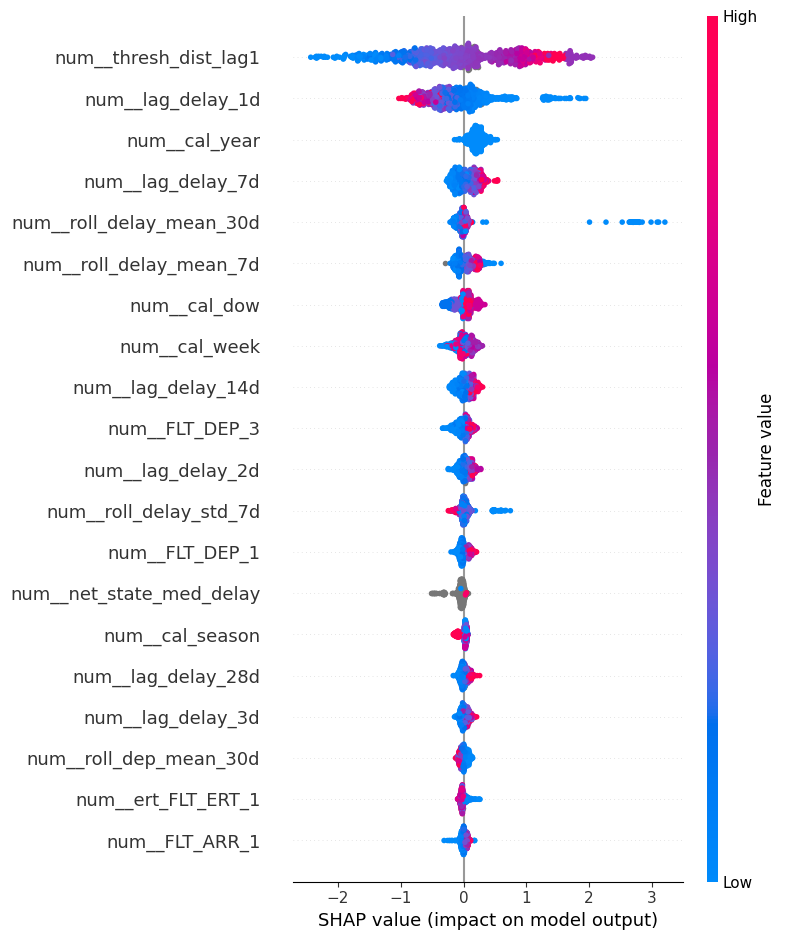

In [75]:
from sklearn.inspection import permutation_importance
import shap

INTERP_SAMPLE_SIZE = 5_000
INTERP_N_REPEATS = 5
SHAP_SAMPLE_SIZE = 1_000
TOP_N_FEATURES = 20
TREE_CLASSIFIERS = {"decision_tree", "random_forest", "hist_gb", "hist_gb_tuned", "lgbm", "lgbm_tuned"}


rng = np.random.default_rng(RANDOM_STATE)

n_interp = min(INTERP_SAMPLE_SIZE, len(x_val))
interp_idx = rng.choice(len(x_val), size=n_interp, replace=False)

x_val_sample = x_val.iloc[interp_idx].reset_index(drop=True)
y_val_sample = y_val.iloc[interp_idx].reset_index(drop=True)

perm = permutation_importance(
    champion, # x.val! 
    x_val_sample,
    y_val_sample,
    scoring="average_precision",
    n_repeats=INTERP_N_REPEATS,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

perm_df = pd.DataFrame(
    {
        "feature": x_val_sample.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }
)




perm_df = (
    perm_df
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

print(
    f"Permutation importance for {champion_name} "
    f"using {n_interp:,} validation rows and {INTERP_N_REPEATS} repeats"
)

display(perm_df.head(TOP_N_FEATURES))
top_perm = perm_df.head(TOP_N_FEATURES).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(
    top_perm["feature"],
    top_perm["importance_mean"],
    xerr=top_perm["importance_std"],
    color="steelblue",
    capsize=2,
)

ax.set_xlabel("Decrease in average precision after permutation")
ax.set_title(f"Top {TOP_N_FEATURES} features for {champion_name}")

plt.tight_layout()
plt.show()

if champion_name in TREE_CLASSIFIERS:
    shap_pipe = champion
    shap_model_label = champion_name
else:
    shap_pipe = fitted_models["hist_gb"]
    shap_model_label = f"hist_gb proxy because champion is {champion_name}"

pre = shap_pipe.named_steps["pre"]
tree_est = shap_pipe.named_steps["model"]

X_pp = pre.transform(x_val_sample)
feat_names = pre.get_feature_names_out(x_val_sample.columns)

n_shap = min(SHAP_SAMPLE_SIZE, X_pp.shape[0])
shap_idx = rng.choice(X_pp.shape[0], size=n_shap, replace=False)

X_shap = X_pp[shap_idx]

explainer = shap.TreeExplainer(
    tree_est,
    feature_perturbation="tree_path_dependent"
)

shap_values = explainer.shap_values(X_shap)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(
    f"SHAP summary for {shap_model_label} "
    f"using {n_shap:,} validation rows"
)


shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feat_names,
    max_display=TOP_N_FEATURES,
    show=False,
)

plt.tight_layout()
plt.show()

### Permutation importance findings

`thresh_dist_lag1` is by the most important feature. It has a mean decrease in PR-AUC of 0.183 when shuffled, which is more than three times larger than the second-ranked feature. This also makes sense intuitively, as yesterday's delay sits in pararell to the airport's own trailing threshold (75th-percentile), giving the model an explicit signal of whether the airport is approaching or already in a high-delay regime. The fact that this engineered feature dominates confirms that the threshold design in Section 6 captures the core predictive signal.

`lag_delay_1d` ranks second (0.055), and it confirms that the most recent observed delay is the strongest raw signal after the threshold distance. The drop-off to the rolling features (`roll_delay_mean_7d`, `roll_delay_mean_30d` at ~0.013) is sharp, and it suggests us that the model relies primarily on very recent history rather than longer-term trends.

`cal_dow` (day of week, rank 5, 0.008) is the highest-ranking calendar feature, reflecting the well-known weekly traffic cycle in European aviation, weekdays and Fridays carry structurally different delay profiles than weekends.

Traffic volume columns `FLT_DEP_1` and `FLT_DEP_3` appear at ranks 6 and 8, confirming that busier days are associated with higher delay risk, consistent
with the positive correlation observed in the EDA.

`ert_FLT_ERT_1` (rank 11, 0.003) and `asma_TOTAL_ADD_TIME_MIN` (rank 13, 0.002) both appear in the top 20 despite their high null rates (~37% and ~43%
respectively), confirming they carry genuine signal for the airports where they are available. `APT_ICAO` (rank 14, 0.002) also contributes, consistent
with the strong per-airport heterogeneity seen in the EDA boxplot.

Features not appearing in the top 20 — including most ERT delay cause codes,
the state median feature, and longer-horizon lags — contribute little
incremental information beyond what the top features already capture.

---

### SHAP findings

The SHAP beeswarm confirms and deepens the permutation importance story,
now computed directly on `lgbm_tuned` rather than a proxy model.

`num__thresh_dist_lag1` dominates with a wide spread of SHAP values in both
directions. High feature values (red dots, meaning yesterday's delay was well
above the threshold) push predictions strongly toward high delay — SHAP
values reaching +3 — while low values (blue dots, meaning yesterday's delay
was well below the threshold) push toward normal. The asymmetry is notable:
the rightward tail of red dots is longer than the leftward tail of blue dots,
meaning extreme proximity to the threshold is a stronger positive signal than
distance below it is a negative one.

`num__lag_delay_1d` shows a similar but weaker directional pattern — high
recent delay (red) pushes right, low delay (blue) pushes left — but the
spread is much tighter, confirming it adds information beyond
`thresh_dist_lag1` but is clearly secondary.

`num__cal_year` appears third in SHAP despite not ranking prominently in
permutation importance. This discrepancy is worth noting — SHAP measures
the contribution of each feature given all others are present, while
permutation importance measures the cost of removing it. `cal_year` likely
captures a slow structural trend in European delay levels over 2016–2026
that the other features do not fully account for. Its high SHAP rank also
suggests a distributional shift risk: the model has learned a time trend
that may not generalise cleanly beyond the training window.

`num__roll_delay_mean_7d` and `num__roll_delay_mean_30d` both appear in the
top 6 of SHAP, confirming that medium and longer-term rolling averages add
signal beyond the immediate lag. `num__roll_delay_mean_30d` shows a
particularly interesting pattern: a small cluster of high-value red dots
with large positive SHAP values well to the right of the main distribution.
These are airport-days where the 30-day average was unusually high —
persistent delay periods — which the model correctly identifies as high-risk
even when the immediate lag is moderate.

`num__cal_week` appears at rank 8, just above several lag features. Its
presence alongside `cal_dow` and `cal_season` confirms the model is learning
fine-grained within-year periodicity — not just which day of the week but
which specific week of the year, capturing effects like school holidays and
peak travel periods that `cal_month` alone would smooth over.

`num__cal_dow` and `num__cal_season` both show mixed red/blue patterns near
zero, meaning their direction depends on the interaction with other features
rather than having a simple monotonic effect. This is consistent with the
near-zero linear correlation observed in the EDA — their relationship with
the target is non-linear and context-dependent, which is exactly why
tree-based models outperform logistic regression on this task.

`num__net_state_med_delay` sits near zero with very tight SHAP values and
mostly grey dots, indicating the feature is nearly always missing (imputed
to the median constant) for the validation sample. This confirms the earlier
finding that ERT country coverage gaps limit its usefulness in practice —
it is a conceptually valid feature that the data simply cannot support.

**Overall:** the model's predictions are primarily driven by recent delay
history relative to each airport's own baseline, with secondary contributions
from traffic volume, day of week, week of year, and longer rolling windows.
External signals (ERT, ASMA, state median) contribute but are limited by
data coverage. The feature engineering choices in Section 8 — particularly
`thresh_dist_lag1` and the per-airport rolling windows — are validated as
the most impactful design decisions in the pipeline. The prominence of
`cal_year` in SHAP is the one finding that warrants caution: it suggests
the model has partially learned the shape of the 2016–2026 period rather
than purely generalising from structural delay patterns.


### Failure Mode analysis


Test set total rows                      : 62,676
False negatives (missed high-delay days) : 6,394  (10.2%)
False positives (false alarms)           : 16,161  (25.8%)

Top 10 most confident false negatives:


/Users/alejandrozapata/Documents/IE University/Courses/2.2 Machine Learning Fundamentals/Machine_learning_Project/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,FLT_DATE,APT_ICAO,STATE_NAME,y_true,y_pred,proba
0,2024-02-08,EGKK,United Kingdom,1,0,0.040770
1,2025-11-26,LGAV,Greece,1,0,0.042187
2,2025-03-05,EGKK,United Kingdom,1,0,0.043696
3,2024-03-09,LICC,Italy,1,0,0.048904
4,2024-01-17,EGSS,United Kingdom,1,0,0.054096
5,2024-01-15,EKCH,Denmark,1,0,0.055259
6,2025-03-25,EGKK,United Kingdom,1,0,0.059675
7,2025-12-17,LIRF,Italy,1,0,0.062014
8,2024-11-21,EGKK,United Kingdom,1,0,0.063462
9,2024-02-06,LSZH,Switzerland,1,0,0.064899


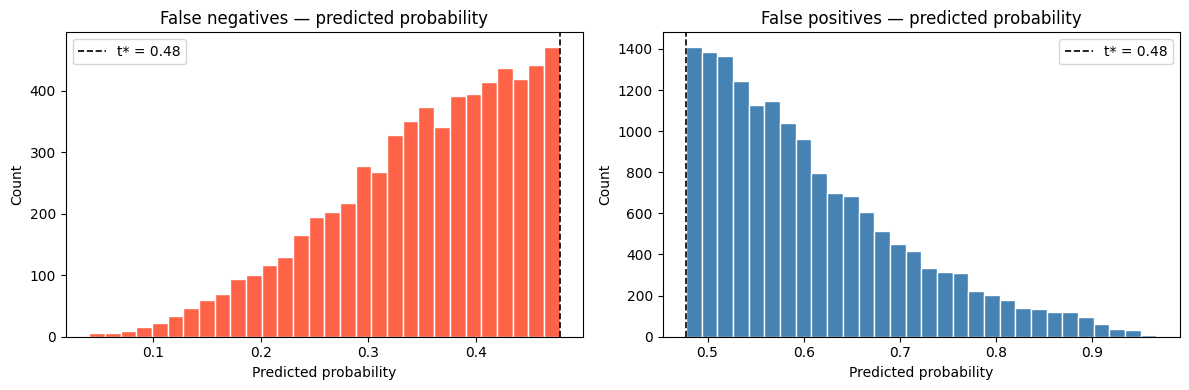


Airports most frequently missed (false negatives):


,false_negative_count,count
0,LFBO,130
1,EDDS,129
2,EVRA,125
3,GCRR,121
4,GCTS,118
5,GCXO,117
6,EDDK,114
7,EDDM,114
8,LFLL,112
9,GMMX,106


In [76]:
# Failure mode analysis — identify where the champion model is most wrong
test_proba_all = champion.predict_proba(x_test)[:, 1]
test_pred_all  = (test_proba_all >= t_star).astype(int)

test_results = x_test.copy()
test_results["y_true"]   = y_test.values
test_results["y_pred"]   = test_pred_all
test_results["proba"]    = test_proba_all
test_results["FLT_DATE"] = test["FLT_DATE"].values

# False negatives — high delay days the model missed
fn = test_results[(test_results["y_true"] == 1) & (test_results["y_pred"] == 0)]
# False positives — normal days the model incorrectly flagged
fp = test_results[(test_results["y_true"] == 0) & (test_results["y_pred"] == 1)]

print(f"Test set total rows                      : {len(test_results):,}")
print(f"False negatives (missed high-delay days) : {len(fn):,}  ({len(fn)/len(test_results):.1%})")
print(f"False positives (false alarms)           : {len(fp):,}  ({len(fp)/len(test_results):.1%})")

# Most confident false negatives — model was most certain it was a normal day but was wrong
print("\nTop 10 most confident false negatives:")
display(
    fn.sort_values("proba")
    [["FLT_DATE", "APT_ICAO", "STATE_NAME", "y_true", "y_pred", "proba"]]
    .head(10)
    .reset_index(drop=True)
)

# Probability distribution of errors
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(fn["proba"], bins=30, color="tomato", edgecolor="white")
axes[0].axvline(t_star, linestyle="--", color="black", linewidth=1.2, label=f"t* = {t_star:.2f}")
axes[0].set_title("False negatives — predicted probability")
axes[0].set_xlabel("Predicted probability")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].hist(fp["proba"], bins=30, color="steelblue", edgecolor="white")
axes[1].axvline(t_star, linestyle="--", color="black", linewidth=1.2, label=f"t* = {t_star:.2f}")
axes[1].set_title("False positives — predicted probability")
axes[1].set_xlabel("Predicted probability")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

# Which airports appear most in false negatives
print("\nAirports most frequently missed (false negatives):")
display(
    fn["APT_ICAO"].value_counts().head(10).reset_index()
    .rename(columns={"index": "APT_ICAO", "APT_ICAO": "false_negative_count"})
)

On the test set of 62,676 rows, our best model produces:

- **6,394 false negatives** (10.2%) — high-delay days it missed entirely
- **16,161 false positives** (25.8%) — normal days it incorrectly flagged

The false positive rate being 2.5x higher than the false negative rate is a
direct consequence of having a low threshold `t* = 0.48` selected to maximise F1
on validation. At this threshold the model is deliberately cautious which means that it
accepts more false alarms to reduce the risk of missing genuine high-delay
days, which is the operationally correct trade-off in an ATC context.

**False negative probability distribution**

The false negatives are almost entirely clustered between 0.3 and 0.48 which is just below the threshold. Critically, there are very few false negatives near
zero. This tells us the model is not completely blind to these days since it
assigns them moderate-to-high probabilities that fall just short of the
decision boundary. These are not genuinely unpredictable events; they are
borderline cases where a slightly lower threshold would have recovered them.
Lowering `t*` from 0.48 to around 0.35 would recover a large fraction of
false negatives at the cost of further increasing the already high false
positive rate.

**False positive probability distribution**

False positives are concentrated just above `t* = 0.48`, with the mass
falling rapidly as probability increases. This means the model is not making
overconfident false alarms therefore the vast majority are borderline cases where
it assigned a probability of 0.48–0.60. Highly confident false positives
(above 0.80) are rare, which is a sign of reasonable calibration consistent
with the calibration curves in Section 14.

**Most confident false negatives**

The top 10 most confident false negatives are concentrated at UK
airports and include dates in early 2024 and late 2025. EGKK (London Gatwick) appearing three times is notable: Gatwick operates with essentially no spare runway capacity, meaning any disruption cascades rapidly into severe delays with little warning in the preceding day's lag features.

**Airports most frequently missed**

The most frequently missed airports are LFBO (Toulouse), EDDS (Stuttgart),
EVRA (Riga), and the three Canary Island airports GCRR (Lanzarote), GCTS
(Tenerife South), and GCXO (Tenerife North). The Canary Island cluster is
particularly revealing since GCRR, GCTS, and GCXO together account for 356
missed high-delay days. These airports are heavily dependent on charter and
leisure traffic which operates on seasonal surge patterns that the rolling
lag features struggle to anticipate, since the delay spikes are driven by
demand shocks rather than persistent congestion.

**Key takeaway**

The failure mode is not random, it is structurally concentrated in airports
with volatile, demand-driven delay patterns (leisure hubs, constrained
single-runway airports) and in borderline probability cases just below the
decision threshold. The model's backward-looking lag features are well-suited
to airports with persistent delay regimes but systematically underperform
at airports where delays are sudden and exogenous. Incorporating weather
forecast data or published traffic demand figures would be the highest-value
improvement for future iterations.

## 17. Reflection

**What worked well?**

The temporal split design and per-airport threshold prevented leakage
effectively throughout the pipeline. `thresh_dist_lag1` emerged as the
strongest feature by a wide margin. This was an intentional design decision that paid off
clearly in the permutation importance and SHAP results. Gradient boosting
models (LightGBM, HistGradientBoosting) consistently outperformed simpler
baselines, and the tuning grids produced marginal but consistent gains.
The calibration curves showed that the champion model's probability
estimates are reasonably reliable.

**What did not work? What were some of our limitations?**

Regression performance was modest (R² ≈ 0.36 on test), meaning roughly
two thirds of day-to-day delay variance remains unexplained. The primary
bottleneck is the absence of weather and NOTAM data since sudden events 
such as storms, strikes, or military airspace restrictions are the main drivers 
of extreme delay days but leave no footprint in the precedingday's lag 
features. This was confirmed directly by the failure mode analysis: 
the most frequently missed airports (Canary Island leisure hubs,
constrained single-runway airports like Gatwick) are exactly those where
delays are driven by demand shocks and external disruptions rather than
persistent congestion patterns. ASMA and ERT coverage gaps also 
limited the contribution of external enrichment sources. 
`net_state_med_delay` in particular was nearly always imputed 
to a constant, contributing almost no signal.

The false positive rate of 25.8% on the test set is higher than ideal.
This is partly by design. The threshold `t* = 0.48` was selected to
maximise F1, which accepts more false alarms to reduce missed high-delay
days but it also reflects the model's tendency to be cautious on
borderline days. In an operational setting this rate of false alarms could
erode trust in the system over time.

**Ethical considerations and bias**

The model is trained on 2016–2026 data which includes the COVID-19 period. 
The structural collapse in traffic during that period and the
uneven recovery across airports and countries may not repeat in the same
form, introducing distributional shift risk for future deployments.
`cal_year` appearing as the third most important feature in SHAP suggests
the model has learned a time trend that may not generalise beyond the
training window.

Airports in countries with poor ERT coverage (Israel, Luxembourg, Morocco)
and airports in the Canary Islands which are structurally unmappable to
a single Spanish `STATE_NAME` in ERT receive systematically weaker
predictions. If this model were used operationally to prioritise ATC
resources or issue flow restrictions, those airports would be
disproportionately underserved, raising fairness concerns.



**Group collaboration**

The project was divided across six members, with each person taking clear ownership of a specific area. All members collaborated both through GitHub and in person. While individual commits were used to track many contributions, some parts of the work were completed collaboratively during in-person meetings. In several cases, to keep the notebook consistent and avoid version conflicts, we worked from the same laptop, passing it between team members while discussing, editing, and reviewing the code together.


| Team Member | Responsibilities |
|-------------|------------------|
| **Andrés Béfeler** | Exploratory data analysis (EDA)<br>Classification target<br>Preprocessing pipelines |
| **Jose Miguel Reyes** | Panel construction and QA<br>Class imbalance handling notes and distribution interpretation<br>Missing values narrative and EDA write-ups<br>Slides: Modelling, testing, and performance |
| **Alex García** | Regression target definition<br>Regression baseline models and diagnostics<br>Feature selection and leakage audit |
| **Alejandro Zapata** | Research on data sources<br>Pipeline fixes<br>Early data loading<br>Slides: All topics after the intro and before modelling |
| **Javier Cruz** | Optional LightGBM handling<br>Pipeline fixes<br>Path A scaffold |
| **Nicolás Gonzales** | README rewrite and submission polish<br>Slides: Intro and conclusion<br>Baseline model training sweep |

The main lesson learned collaboratively was that Jupyter notebooks are painful to merge under version control. In future we would modularise all helper functions into separate `.py` files and use the notebook solely as an execution and presentation interface. This would have eliminated the merge conflicts we experienced when two members edited the same notebook simultaneously.